# Identificación de procesos ARIMA
## Definición de funciones para el análisis
### Bibliotecas de funciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf

### Datos de las series

In [2]:
series = [[0.47143516373249306,-0.955258112840218,0.9550779120059883,0.16488705991128128,-0.638145203409371,0.5680903386030531,1.143633583018943,-0.06470671290787755,-0.016656984339509857,-2.2510134463551603,0.024529001542237916,1.0042105231137968,1.4554293896693289,-1.293540125360306,-0.98084742848825,-0.48830534956063854,0.16130073678987172,0.3697423093749712,1.506029346816871,-0.7938908798208046,-0.5995917645395842,-0.955765226408726,-0.2844612367340047,0.41120829258973957,1.5237557004750064,0.2925725655316036,0.8218403678881826,-1.4061070426461055,-0.8861620615020515,0.6158881568201247,-0.08989614978992905,0.2924895787190078,1.1938233622522256,1.642849936753778,1.6851422600617276,0.7204795551831895,0.4849527313598106,-0.08031843992839036,0.8015154930319465,2.791718261979006,1.4720587188267393,0.16958342894841283,0.12093365115827913,-2.0145107751108897,-0.7594631878068983,-1.276888378343148,-0.7752390224329213,-0.36933031986724135,0.5707488224645147,0.5006429922017008,1.0913302910322416,-0.9001449315281855,-1.8520457472649365,-1.0269410735813822,-1.061712985977546,-0.6754760013581573,0.016282331520159232,-0.027371859518060586,0.5520523763035649,1.82168499277734,-0.06339383737864546,-0.10204179579342515,0.25694795731932163,-0.08002478444621894,0.9937883403323897,-1.9035594636461008,1.0788238890157493,-0.6032193445148888,-0.08972628547974335,0.6598574815772371,-0.4555064709745784,0.23430650167475947,0.821381476299554,0.9341987060435863,-0.45915496050843274,1.7782654705237841,1.1160952771327874,-0.5946114706845587,0.3346737104668501,0.20684954192679178,0.567817096014292,-3.279608112617589,-0.31869844083858867,-0.00671866821475986,0.1611702088250186,-0.34951058646397826,0.5926134425204224,1.281226563170108,0.911449130411858,1.8477107586523362,1.003697692334797,0.10188426547087603,-0.9769084259464678,-1.0731724242340221,0.2800077144308307,0.05805680538875002,-0.3157376115602693,0.37041933951725947,-0.8837791137215024,-0.9537708659875663,-0.18568007325071967,0.4736936597282126,0.7404385889753093,0.6555149792695117,0.8120456023845058,1.7695043136183985,0.10364687318380728,-0.41619422974558185,1.0164772402533835,-0.7728696550173508,0.489040676765649,-1.4661949856467045,-1.1838625959596265,0.1572325079392518,-0.12531661213162532,-0.24483371773154683,0.558239145515683,-1.5393794176337727,-0.7226180734911752,0.0335351725816167,-0.2316644680900383,-0.7335388820420359,-1.049653437470352,-0.08856911439425913,-1.7472973313103675,-0.47993806651651855,-0.7192930368337566,-0.6586628113829587,0.36477188198728494,0.861015614703499,0.6700638023556464,0.4862585304722731,1.0592564985961774,2.4231627168942893,1.8512141216408473,-0.03642177108476774,-2.1034765276624934,0.878508503634329,-1.2960946226532282,0.5623363935779002,1.0786036162168235,0.15949102406103277,0.7823077360321168,-0.4591924036390566,0.9472162482854005,-0.05072797848975574,0.6755437416707268,1.321959941557779,0.5392515621120693,2.6353944098960733,1.8138401311956314,1.703514932262768,0.37773657600569893,0.13217257151191994,1.4238835438630182,-0.09289195223519464,-2.1700662252105274,-1.418535553038511,-1.5959871290046337,-0.463795633603308,0.30488600810109623,-0.5913873638856532,-0.6158975641837057,-1.2241476433583938,-1.4717421216609377,-0.5098855740967134,0.3738330394899376,0.3734108685180435,1.1391837793681436,1.5577294722773807,0.7062564221760148,-0.19747471247541193,-1.0368899703308103,-1.7575165477601977,-0.7390749998488042,-0.5925564818068781,1.827413647690114,1.035980258103886,-0.8914416108708257,0.9772651473368303,-1.6592224639751947,-2.177143745445352,-0.7250073159160277,-0.3772557697626087,1.0837671936649054,-0.9076830120309349,-1.6493652476824383,-1.4165455969884682,-1.1227776420264237,-1.9871835544512333,-0.7841969896896929,-0.9849844986837719,-1.9656086628075333,-1.8793849467056378,0.16465909650749366,-0.3492199672622979,-0.33574689187520784,0.7212840481352698,0.6490188717829003,-0.7270295016785879,-0.6830761506795254,-0.9615311630609649,-0.3237672050837934,-0.733338953621686,0.6909637063937712,-0.44600695628099984,-0.7476308240689701,-0.3019373726641163,1.7597907409451248,1.6678600536101769,1.3470121712720804,0.1270898053624463,1.1074895581765463,2.661529931881643,2.7906924475261152,2.410751681575578,1.9545604417119864,0.301758742419305,0.591145762878382,0.9845447377661333,0.21562624160607935,2.03234644081833,1.4273772411163888,1.6044535767313115,1.0285900156173626,-1.5643228858934939,-1.1700476749139228,-0.6721308074209604,0.7903204184267927,0.6422719253711326,0.44230776801710725,0.5201378195506002,0.10296977292864842,-0.6889841363163937,-1.5921449912094296,-0.5466172804522654,0.30776468039447374,2.917726420046803,1.8581886470029778,1.5975824927072946,0.5230175176973422,0.7619916590030433,1.2440606900921463,-0.42959751441913907,-1.6068528347026565,0.3504958232608971,1.3571920176296806,1.0699674572367714,-0.3460633635831837,0.12204827799464807,1.9248252011298284,-0.7498613239063415,-1.7820152076963962,-0.7642264175212263,-0.37835336096511724,-1.4581709365559503,-1.567928389698265,-0.23004294340941234,-0.6190641897866698,-1.0979722794112137,0.9804145347783244,0.6956621213151418,0.6608441896384312,1.196942806987515,0.8975419330881339,1.525311610390189,1.1258331527395469,2.456596401921616,0.7425454566779998,0.7589471841165985,0.4030312024508528,-0.4587139008188535,-0.548041879987441,-0.9966831336680932,-0.3209548474494476,0.8230353056184405,0.435022238694615,0.7712880972106735,0.7394133426019764,0.09411303753330597,-0.4434270727120284,-0.5961501365487949,-2.6955790444132135,0.19324046107133186,0.159704769492971,-0.20458829917980725,-1.3678946871911144,1.1040322888601926,0.19750743636072204,-0.006007404886743228,0.3832499867456809,1.0144003671382138,-0.17658963886190093,0.9689085117831788,0.516334229460621,1.601349572259252,0.7501350965808535,0.01105759198331796,-1.5478135434394018,-1.093204573539862,-0.019555835814966782,0.7013344814573395,0.13312176023819358,2.7043520908229604,-0.3899615851834852,-0.28941560033318675,1.2864759520879705,1.235996422594654,0.788295106623615,-1.357558394480217,-0.39019787489690066,-0.7376784543552296,-0.19723684519161983,0.8841994066472949,0.41675080126087866,-0.07917704865366873,0.8848543430165318,0.3811808716419513,-0.5404429067642305,-1.292995158077258,0.3494953912071235,1.1303056282310169,1.2789935853105519,0.7728677548493978,-0.4206044310481145,-0.5523129974032723,1.6326231593895502,0.9722348411479018,1.2457699526669135,0.1998787479142084,0.28161211928078583,0.4152986303867964,0.2755616725741554,0.10079802141115826,-0.12040201999204327,0.2067722215438461,1.4863833596248486,0.7207308063009977,0.49176077037641397,0.6803175702904394,0.6046928534622185,0.8680047710049339,1.0190866650041914,0.33524517975000834,-0.9037460815800855,-0.500333543342426,-1.0954571612374564,-0.13262802223714742,0.3592165802792846,-0.8011160673609435,-0.8283841436524924,1.0843778833122908,0.18203237078711743,-0.3672242039439341,-1.5215805039229375,-0.8021767915763407,0.4199595603197446,2.307780560931564,2.436823527340305,1.4887496894095245,1.7475152067496937,1.9524311546952535,1.3169682624773908,0.4604091716151271,2.711663008683217,2.741086380530815,0.21594222487573855,-1.1600979379392122,0.027813217239873622,-1.0661898745376541,-1.1443766120645893,-0.4701531937399634,-1.6716505336421004,-0.625108214315395,-1.2094582778552097,-2.329122217919438,0.6277780876872234,-0.9988236627486198,0.056465595011315095,-0.6536485079854731,1.2459184917630677,0.5183076710337678,2.109551637126785,0.7214253918139919,0.5541769297268684,-0.21965647300147484,0.9228949792351233,-1.2783563079049975,-1.3950403295754077,-1.5786318974356393,-0.39542368580514425,-1.1477373776988553,-0.24136206668717852,0.4082633755124574,-0.9163893062364963,-0.4099304461925915,-0.14297677257451818,-1.0990040595051265,-0.7878373952198893,1.5382594719714018,0.542497442308865,-0.6525819990224906,0.029547997961575034,-1.255289479405501,-0.8231171523995091,-0.8749779754172178,0.5519258595772418,1.664610311420338,1.9200188922343102,1.3988107091515458,-0.2621968863054631,1.1145114939951146,1.0601812646681894,-0.10130814604442462,-0.7549061201104723,-0.6179355968135785,0.2766315125230684,0.49111631636994074,-1.5699995342471154,-1.6951236128186995,-1.5960897597484092,-0.9061698063544676,-0.17830606612506605,0.1481967314468921,-0.18574532863994245,-0.40531484147637115,0.24585232177422126,0.06339419618271011,-0.4383177153064316,0.13040791397444979,-0.9622648901863879,-0.7877709289628048,1.0122906750128653,-0.7435514352879202,-1.931924606529193,0.591435347384426,-0.29763872128427515,-0.31910787297163806,1.5130728719688873,0.21573662833456841,-0.5762600145993004,0.31183207868234275,-0.061283085803466725,0.30088497545041953,-0.2329220924256182,-0.89827713428592,-0.18290116031512366,0.18797744437517547,-1.1256369729861824,-1.2867674032485956,-2.3781620091682325,-0.9174202202100918,-0.35959809315595564,-0.542888953015236,-0.8596712047961368,-0.40389388887393635,-0.7742492951821268,0.7184623152060978,-0.8487844352265985,-1.764093257588215,1.193138777937675,-0.8928403123621729,-1.5973732218070507,-0.37962678622955953,0.22359188330971644,0.8293728742431411,0.6764112768014754,0.09543436730037538,-0.45355094910147925,-0.9249044535195947,0.9221279340792766,0.1746385531038826,0.5873888615801673,2.2447976673301446,0.8440313720720637,0.4588019446667423,0.6752534785943725,-1.0727240183834832,-0.0863607084962667,0.4722991765457649,-0.9179343521097204,-1.8391405711266984,-1.415403290776512,-1.1209807178071272,-2.279807026831113,-1.1694644161686412,-1.3507720916071495,-0.5755039693009475,-1.000775941280218,-2.726505591617696,-0.6375386426868929,0.5982069617257888,-0.26478675954836095,-1.6545729365973512,-0.8415652569262378,-0.6675034352820032,-0.4990811941582808,-0.13042661448079912,-2.140193793410447,-2.0728521137221403,-0.5128800387972712,0.5650772896002866,0.1337967954672807,0.02152798577434839,-0.6937289326425867,1.3834510531850468,0.9206527820965769,1.5530674483391278,0.42296219750813646,0.1808222338172841,-0.10976073371203425,-0.5361906062132913,1.4433306939049304,2.1570524332050867,-0.08899411663846268,-0.0036536335532296182,0.36019137889383057,0.7526878804901609,1.4808041769782299,0.3147300619685218,0.9130538738329509,0.46680839407180297,0.45798996780079804,-0.9057132426678904,-1.4043775625655015,-0.8293192373585173,-0.38571512027813526,1.9112198064902377,2.523124046708835,0.6373323905635442,-0.08197800677820416,-1.1780505415982265,-1.492184307795993,-1.8433702163170282,-0.9929943177896134,-1.8158362455456603,-1.4680110686499015,-0.5690509772915868,-0.9161112765702458,-1.3251254178478915,-1.6651253796346106,0.3747855134283682,1.8993797697001762,0.3251004055483756,-0.04959560121177076,-1.2183619828802301,0.04840490099306327,0.2242823320489259,1.2034010252462148,0.11267845434939788,1.424559489400657,1.6039048622271368,1.6395186435637057,1.3339040351710996,0.616902325175716,1.0524040087527518,-1.1978481991617507,-0.5090225263081469,0.06822829873112651,-0.3430352762459933,-0.17173853642459602,0.9642444255669235,0.313423100565947,0.9545880467041361,1.0298183365100657,-0.6381840935491481,1.3224601422542306,-0.7777477633471275,1.6388656321439559,-0.5458845051016861,-0.20079339015855802,0.5127549833453653,1.7455439179669279,1.094068534018085,-0.9838578413775716,0.30995929352769824,-0.26948706609949014,0.984111439086119,2.0616037841259063,2.4585336631305887,-0.14257104155139944,-0.33770341341789606,0.6103628585052937,0.20236713456763283,-0.48528105447457104,-0.0023878726422357777,-0.999249595092657,-0.30845488472312377,-1.1070304639424706,0.9174813475337706,1.1776455953097833,0.42226322037798314,0.9757429068772117,-0.7015720174092553,-0.8856432724248917,-0.46441948285909634,-1.337401332909334,-1.7246470049796025,0.15903215650025437,1.7891721732300003,0.9241480385526175,0.5859160357145464,0.5823880745602485,-0.010298206666422227,0.4092859079465998,1.154500855111082,1.099098969665064,-1.4197133892193072,-0.20704666685186957,-0.4579457727596951,-0.6759633681912424,-1.4549600700313914,-1.5157464175967925,0.2978789551674671,-1.155601733313253,-0.03806562931383106,0.32795843571645367,1.038172111188776,-1.056093307026368,-0.688030309688135,-0.9873483910110306,-1.2090450821368104,1.0949363895532238,1.8303054194633104,0.4625950434134469,0.6250976488225516,0.7382894349970719,0.23909728530694083,-0.2741845235280915,-0.7781520358721994,-0.21711176322064712,-0.9487049009036694,0.390645858073122,-0.009538403044901084,-0.11184253585498895,-0.2980279529922136,-1.0514967514332565,0.27212251060300297,-0.1530345323556465,0.6004603464879328,-0.04295386068657098,0.46573320426455966,0.9985319602950908,-1.7012984555965736,-3.4467116245774623,-1.247680974172218,-2.2187261323183423,-2.2194397978252116,-2.1081263944310313,-3.329869799762178,-0.11212769201455242,-1.2053626146815921,-0.41415067874315614,0.7818884437154037,-1.1951920814352532,-1.0699769162613904,-0.7238348060064377,-0.1507903226748141,1.5363271311184907,1.3348940073724755,0.026269750220852206,1.5519088162704313,1.0856183940301694,0.09396051666305671,1.8160808286440895,1.1762409022858156,-0.8741046107823259,1.413757863581039,2.4076484374614826,1.5572152746790549,1.1150966584417195,1.6146537636631377,2.006005604299236,-1.5916514675122648,-1.5105711079127242,0.04906048768262572,1.2161855897131697,0.48072741074024883,-0.8346115606185689,1.030963344874693,0.23712739272170852,-0.918254967580086,-0.25767601740778856,0.372917790286835,1.799793817154879,-0.997813719673063,0.8001757139397473,0.9532722829421758,0.27627384546442646,0.6838069178252631,0.6041900778858014,0.5211652486232861,1.1929355565801243,2.3395202061709104,1.0450564233156057,1.4765598787929506,1.450330888621366,0.1458287870949907,-0.6889050619685633,1.317049597759483,3.206216501337458,1.564195926639616,0.425688756081556,-1.6497242753934178,1.8271369804375024,0.7773381198624161,0.4924183999021743,0.3616414256357429,0.43949117727391007,1.7074889205984123,2.308087936689839,1.8583522665130179,2.3955275091131805,1.551385937093353,-0.30983049502126514,0.2082945134923363,-1.70912987565916,-1.052475697545414,-0.09336325672342849,-0.5872474160694046,0.002006946946192689,2.0808477103067977,-0.8020090648076477,-0.9121705490243956,-1.0370204029069379,0.5442262652118376,0.2901682422621989,0.16788252082047073,-1.5958502245047008,0.014497888430154204,-0.6186397622510249,-1.559590699594239,-0.1646598914431685,-0.2037245567353794,-1.3827575497052462,-0.366768968927369,0.48718490615376875,0.39275377622025986,0.5234406919930271,-0.09124134414530821,-0.9511483125163248,1.200611269318299,1.28130164238592,-0.06306678940044774,0.07054635400966683,1.2303293166893128,0.3372052725630475,0.1164373446516834,0.41190227357565573,-0.20235962532272608,-1.9116094804565509,-1.8591128025083832,0.12448868993512197,-0.9186325317614221,-0.10723737447633269,0.6123631530724374,1.3716830784910403,0.45740792614281756,0.5931878673172359,-1.218252723556815,-0.6843876490156333,-0.6392519062651928,-1.0470403349058583,-0.7693955078385084,-0.5126466960388867,-0.625633967928905,-2.935821268441983,0.6479400947035758,1.009531632830932,0.34732183170371567,1.5549486832648651,0.8459009003743149,0.7354867426705438,0.8219965564856341,-0.37747359705903344,-0.25457713284067623,-1.545768412530029,-0.9126375464759356,-1.0116736294510664,-1.0077545935775476,0.18924122471499183,-0.15073988449266879,-1.3448018013321887,-0.9347247558501655,1.8702361042699733,0.15340061445895647,0.15680005276772893,-1.2610110943814434,-0.21705458336555583,0.09592467566587637,0.5264156323626386,0.29278878715655626,-0.036047590820660474,-0.0005571202755201288,2.054010969865052,-1.5048778284575044,-0.3286242301904987,-1.1199956306858854,-0.6936720256647219,-1.4242393375418219,0.5377828419202465,0.8400401744232262,0.7170685163690687,1.230399475686161,0.4514885412688504,0.9152674694223597,2.4422236379010664,1.1028299338565206,1.5065448858515331,-0.42728044327200376,1.2568337176604367,0.6068589752071907,1.0142909586730737,-0.304689572738187,-2.4035578516589386,-2.3278791118213094,-1.47180630182755,-1.6977876865535975,-0.17806788395758022,-0.025650515387226333,-0.6696211381578459,-0.623173751531643,-0.5313803715103379,-0.06544222494824417,-0.8782213535047877,2.2038120079533177,0.768161233313091,0.2385722564840373,1.0126548359237095,1.7948821564158357,1.2286392662194014,0.538951735003381,0.20832821197878645,1.9602209724379613,0.22706920376285178,-0.22669126788318067,-0.664341673247891,-0.9362081628761552,1.654485878165385,0.8475484598135768,-0.4424858245405476,-0.5771312985931081,-1.2429079600655282,0.9700101340644018,0.4855924050688211,-0.22123552928356113,-1.6343285509510799,-0.6622939101274681,-1.1717962990446427,-0.5752123670113194,-0.8313465739611683,0.25978205668192067,-0.8434511848901047,0.39662250990135306,0.08229396949688407,-0.6497112296093491,0.714099860899218,1.338321778478198,1.285781692803258,-0.14459618593352475,-0.05144135621229692,0.5736192269302225,-0.09138564920823528,-0.10116159148356062,1.9329072587520457,1.0443416574038968,0.9267552431506938,-0.3856318883314682,-0.2709057432531098,-0.6627651122463145,-0.5740704897591862,0.8199146011289468,0.3744273854926679,-0.7727012909657506,-1.0153016202859222,-0.23913598743790038,0.36879281913677286,0.7712350116833773,0.21022476475089888,-0.32831387446670857,-0.12048492582600859,-2.4291353941920333,-2.8072888325618877,-3.845315156523776,-2.1853914065317976,-1.9153140219767617,-0.9999253493202055,-0.8912328754975538,-0.2150359378355416,0.22104592437077278,0.94857154613867,-0.43359583969180954,-0.25854343310653705,-2.1236073599583998,-0.9536394241599183,-1.0661054010861768,-1.5180329341675782,-1.7951938667951146,1.1420891037613619,-0.08771253205924145,-0.6518398271998131,0.5405329882459005,-0.4712029953049769,-1.7061629708565076,-0.14460736437376598,-0.20081607960798806,-0.2610478693255083,0.9466462746623846,-0.14007426482372837,-0.7818007637241632,-0.325461842526775,-0.5842017545744593,-0.6333177609616636,0.9953776262685935,-1.325243674700447,-0.44724591078856235,-0.8943362837101556,-0.18745066817610972,0.3758240927727323,0.6801451562329275,0.8522431058002538,-0.7158987034412304,-0.47284321596466083,1.0295533099888314,-0.4144533701856451,-0.01631136458263152,0.9933999469540002,0.3992784830793013,-1.9199577407797632,-3.156900610378374,-0.456182439131269,1.7837507995805457,1.1938861468245854,0.10728143317039024,-0.4599083781809614,-1.3038752490142134,1.5515769317874226,0.47696000857532717,1.584578329963924,1.419109646049686,0.6437440683885555,-1.5219931745052575,-0.6510240445561465,1.6810491046995912,0.08267395284588741,1.0573348165461924,-1.0638257447209138,-0.23954633420761573,1.2172589769925277,0.3653755647018474,-0.04833578402736252,-0.3630971742555191,0.13706742830085214,1.4655724432919606,-0.14702682706717807,0.03830706426798024,0.4507216586079979,1.8391459264797332,0.6221883922322629,1.9500565106395586,1.1091248474848765,0.7265997901001068,-1.0017172592342487,-0.922124312357145,0.4195779924678602,-1.2627775556988998,0.12632095133171461,-0.5734445370898562,-0.3025604292198061,-0.5390949555461709,0.6201159376821974,1.444215134083664,2.4537377620990393,0.5213490361533524,-1.0251359155087583,-1.1507780153076874,0.1253957880720442,0.9438384170682372,-0.1812846014549141,-1.410608203252437,-1.5240167060728003,-0.5993061418405012,0.370106920300464,-0.3890269586143796,0.5491736404853639,0.891299439913233,1.417516553997868,-0.003145240293419449,-0.7372654052959613,-1.3320964854185529,-0.20691053948296956,0.552782936563217,1.0278949451844646,-1.3582361386746324,-1.2353981305565886,-0.34553509953985384,0.7587782030033188,0.7069214326840534,1.0942745168437888,-0.2547677893381254,-1.7095918931001253,-2.4749861613882285,-1.1909311901013506,-2.275294453946393,0.25824510003602863,-0.7158488717840142,0.4560825001580457,0.17829894421082318,0.6233962263562216,-0.4953110164147835,0.5939852361221711,-0.2611800004069512,-0.7597474526259707,0.7977934000747485,-0.44618403376005983,-0.504530924863033,1.4676915905325827,-0.34365375485064553,-1.5501085634162317,-1.0701986955327332,1.093756470296397,0.169440690550488,0.11147827044675362,-0.8664991187013924],
[-1.4167574467150201,1.5719067308295607,-0.636169781824839,-2.007637136609063,0.5288360320353886,0.3154179213958934,-1.7703814749888713,0.9273157729204017,0.4058638843006535,-0.2667958864081689,-0.6254828642745408,1.2225702564877963,-1.8199177274165577,0.9385888528610926,-0.6144907709841211,0.8813758932903868,-2.208189430358255,-0.7770992155744728,0.37068165510642415,1.1213526850537536,-0.9367218981209084,0.9329061058691314,0.025922984330911947,0.8884365666611908,-0.49956934016474663,0.14193424335502566,1.2253751815242815,0.6293596329233258,-1.9654763635298655,0.882734857306283,0.05429591386249902,1.5771882535965485,-1.8025825617859592,-0.26248012650666613,1.1392614896884639,-0.3757841348793468,0.18839008339652788,-0.06683359730086416,-1.903731046446713,-0.6415633653267808,1.5513370301373035,-0.14110209903374876,-0.031178465068545158,-0.7942436494059798,0.8552669634381692,-0.998764589285182,0.029715433976531036,0.201955385224574,-0.6209325496533601,0.3511620040212362,0.2027976626374929,-0.34179412405735254,-0.5250627898788603,1.28946091340633,-1.5733411540656879,-1.6346985254512605,1.1432364692757593,-0.24622588275279483,-0.49669855910184113,0.9978890063395196,-0.5167792873789596,-2.4461446692170767,-0.8315572880270083,1.072183235714232,0.2708387374573901,-0.9334944557451702,0.03112130283055431,-0.23480708593219185,-0.11656415449569923,0.47796214452807906,-0.13568481510181976,1.097162744042299,-0.21111065337417845,-0.4153606678816014,1.9634484593356174,-1.379036469980567,1.800536601536686,-2.1916050644703438,0.7102181792857751,1.8263798946695284,-0.26715195453230245,0.18266582780715185,1.3773624183603346,1.413675835410337,-1.481063067535326,0.2511908022726913,-0.3196174032274728,0.39280229115139675,-0.5292735835873638,-0.7944578469380661,-0.31209790890804223,-0.3052146909539364,-0.49735158659925516,3.136641380749289,-1.324230051361082,-0.9212062447057133,0.36083567250003773,-1.3653907309754019,0.42641551642424635,0.9984940662527142,0.5599938747555477,-0.7142549505521688,0.3987620905930703,1.4218387201424654,1.6613930872902543,-2.5091980706124137,1.8219641484674352,-0.9495504734175184,2.052568497287368,-1.367683502834161,1.6175790686489857,0.5399238759632802,0.44868866254268525,-1.6246312887048662,0.5965157174959832,-0.916328587574977,1.4448867436089283,0.2789228089915702,-1.629386440327579,-0.15649549753406256,-0.5184830645004657,0.8856954393960077,-0.6337607004836834,0.1833749739796623,-0.7249891957570406,1.0197549858130806,0.13288939092333069,0.3387910935642485,-1.3946337823732744,0.12108191855829015,1.0524493878944612,-2.3261866540052973,1.4017352658268907,-0.7804378444266089,0.5739682466186568,-2.137352098878526,1.8743051154962447,-0.1406980146098481,-0.2785662347667236,0.10267011215424965,0.6663709878831505,0.005104348062168418,-1.008037495550561,1.3021362975558723,-1.510635006537975,0.5555765212080228,1.5608971573853083,0.09812507555798355,-0.610073044824877,-0.6558735574023971,1.7637237694616326,-0.6356650677931455,-0.09445134360625745,-0.9001803184062929,1.758169153761386,1.772081467332595,-0.8642123838536839,-1.4271027832973897,3.0162508497735447,-0.5258326583932393,-0.10151437968517366,-0.5799032282820569,0.04578579963806398,-0.14284745478390282,-0.11771480920076502,1.6093483473165315,-1.7419390481155963,-0.9409452170608317,0.049197598848872204,0.8874936255506853,-0.2734692385273265,-1.1366888920486087,0.6281912760391506,-2.150702303972503,-1.1320727599033553,0.984545550543663,-0.4228729303503206,-0.17958858762787558,-1.5733130124615535,2.9123820721383935,-0.3581190259169208,-1.184079021641892,2.3035306149048784,0.6556534739574323,1.4994906619819823,-2.3581138788633798,2.0630766457546583,-0.8897039920362895,0.28144246122634214,0.2856301873006787,0.18874112663539985,-0.8428338685006308,-1.1617010493471391,2.2605486308741307,-0.987477769556967,0.2784797084205589,1.4145691587410034,-1.3475151630624254,-0.46054407019750515,0.3098275855253812,-0.10913421046149283,0.2652292604316145,-0.10021477714163424,0.7665384010602233,-1.4109038823114985,0.08967882636915098,0.9752190525719374,0.13366004038941465,2.3203399320401568,-2.3524995264041055,0.7154863515316017,-0.3920829114576247,-0.7030553846837705,1.547022564391909,-0.4399072647610416,1.1424320727833306,-1.0112028859471325,0.6391528771800237,0.3802717055881147,-1.9100871270241608,0.3999509291000831,0.5879613140512412,-2.212195327475985,0.09752919718920094,-0.8630670195018809,0.7101784807819627,2.500243836514422,-0.6846919840112928,-1.415644462999779,0.38827704477269986,-0.0019725716831373308,0.5467083619976483,0.10680429982110579,-1.055570640176853,-1.0817236195133662,1.3048419887072225,0.6201534178281564,-1.0677725515840892,0.23198730070020696,-0.11820129401048063,0.2686630840206502,0.7241656300390675,-1.0832058864367098,1.5186459420169793,-2.102128051449731,-0.6822386696110545,2.4263377899475493,-1.4646838633467316,-0.38613997377096404,-0.2033125238990175,0.9811643188007422,-1.2461451336850775,1.6555581403199866,-0.0647824277233755,-0.7443830923480945,0.6191100208690083,-0.40193576972487305,-0.25233535898749543,1.1390243377822957,1.449822503369185,-1.0822207741008307,-0.9852856052525323,2.8268283228386824,-0.4122916180219679,-0.6512411816715161,1.2379629702968267,0.32639942690823365,-1.2570340606665131,1.0395432551600174,0.32319944463392786,-0.4466780584968282,0.6365054083726888,0.05486004582074111,1.9351809471848695,-2.823763821326687,-0.6822807569039315,1.824557320757435,-0.909917682061981,2.6734648179483256,-2.0910857669800746,0.6009640656232551,-1.3286836471807544,1.2349265517650672,2.8184563647635423,-0.9084476742121873,1.768159577583041,3.919108437777652e-05,-1.1845865435603562,-1.6486300792536435,2.4997527447898364,-0.18321778840798253,-0.5198988971012506,-1.2668876383301912,1.4313778042895473,1.0392480389489203,1.413847447159971,-0.47886001790811905,-1.397195570563055,0.389755567536067,0.5886260600693661,-0.28196094471522554,-0.49133348705522084,0.251500679527185,-0.7607257462817407,-0.10712335217133806,0.4650311535375139,-0.12584805974932772,-1.5613705699028002,0.4164216685434744,3.293677924375285,-2.1780250543101203,1.2893221210611345,-0.33555242250342243,-1.0582786501804968,0.13071157991410248,1.6752176567661328,-0.5658746183584644,-0.8584034159909182,0.042916856843233875,0.5428383043327085,0.11971719879419115,1.2865936251901569,-0.43376035611251196,1.9608744299576077,-1.7055711828023061,1.105167686267134,-1.072007729127703,0.3883255662510649,-0.7675551669971625,0.6827896614048237,-0.4378599408000843,1.7285143158613772,-1.8074364044511968,1.880554552067363,-0.028848881437822493,0.22674481467119212,-0.7081769881489477,0.3084752180468455,-0.33660478932394877,-0.44156589647562494,0.41703666446455434,-0.7162006693652443,1.264945606039261,0.3703471749870563,-1.086951658881834,0.6755793288502057,-1.1685964547672036,-0.3947387407571279,2.8114768224553703,-3.043772789016481,0.2947408287101454,-0.3743196449773251,0.1608940400578813,-1.8047914593696057,1.529427531411319,-0.26344340932662996,0.703050327331703,0.2573123671249271,-1.3982163418012794,-0.9630726695766058,1.8875237278942465,0.4562446415247634,-0.8328198652306105,-0.37778233020679985,0.18540640083135462,-0.3555605823856969,-0.12055456318455812,1.1081795454508798,-1.0139651640420877,-0.0264872638455399,0.07620156515984781,1.4350346123004907,0.019280099164492692,-1.2230740126234776,0.3851161524106651,-0.7274751966484975,-0.2597375144316582,-0.3634426741437708,-1.1610756721283664,0.3818677658520081,-0.16853679851072323,0.3038840698355796,0.45383913281364185,0.48907117559976293,-1.1832959771388118,-0.227997142935219,-0.1303118688635574,-0.46359278689814093,0.5527701846939346,0.3756531785172492,-0.10163690632065078,-0.8593587396911125,0.009199716899565336,0.7505913400333508,0.06451432449112576,-0.10432983368971242,-0.6494771126809978,-0.6027006086193168,2.626344667993282,-1.1360761632624494,1.577629512509074,0.0199796916923084,-0.9432473633918845,-1.5981183912925419,0.3729861449279561,-1.5024120904564522,0.9624317833263932,-0.5098543023589975,0.48957443181424554,-1.2370778440551653,0.46565799732878066,-0.7916470980159578,0.003867600525787107,1.0605127716378828,0.18757199152012838,-0.5456800663394344,-0.936004523418432,0.9610794245700917,1.547401733330228,0.3155863991608612,-1.5476913640277001,0.005782457131683794,-1.025865484745653,2.2103808451430282,-1.3458352337952566,0.9276616553111963,0.5130605956016161,1.4110249826634813,-0.6456981791526518,-1.983409628436719,0.1745732163006377,0.10716949741908827,0.7651364920331002,-0.40277792256989353,-0.025677554605145043,-0.1331983030556469,0.7334100951638538,0.2956861310365036,-0.16580927375393964,1.087841290122915,-1.634394963187536,0.7919640347563118,-0.8070039266462992,1.6581802528827745,-1.620341844833575,-0.32747780895669487,0.07549266766638046,1.0811989098845467,-0.7753121496494703,1.0811973806326773,-1.3543834148109872,2.3815323426873123,-0.0476606420619351,0.6062970079455805,-2.4741421910927492,-0.43751183743617916,2.3765193872664785,0.2995224203499831,-0.2235643056855665,-0.819255900276194,-0.7043787964785049,-1.356821489708519,1.5964926562116042,-2.135183289276723,2.067852371769651,0.08109004256227237,-0.17585144899890476,0.33557479992777256,1.004309505190852,-0.781679475134938,1.0304984695724577,0.16221693410998173,-0.4305982178174364,0.5149367913757702,-0.8445589371379385,0.6930658445971019,0.09885266130069634,-0.36990673106777355,1.2013496303343494,0.4667525494820183,0.6189517331852986,-2.4331668639758766,1.1111608662789814,-0.8644557650789725,0.08442827497661343,-1.0884700311202349,0.11262895656027128,-0.10069108711388458,-0.8687718582299213,0.9166780025829655,-0.5424844398297904,1.485993648899736,0.9517340049355174,-1.0233686452630089,-0.23887634949092065,0.475590927992537,-0.37597260755342865,-0.5497856587196938,1.2429316678404374,0.734967071546436,-0.705111617168224,-0.30348796115069204,0.7494787456745289,0.10653072047172862,0.2143266154460647,0.5027747135806628,-1.4547266995665638,2.1152488379780214,-0.2201822744066535,-1.018484783166188,-0.22034084560822909,0.7524584181372649,-0.22370175354388858,-0.12361586297965393,-0.29286460219790267,1.7297214985237872,-0.7013908595263842,0.9582572524524443,-0.6208589322984539,1.0616927140495331,-0.9110969613706601,0.3777494723666507,0.7579559284141604,0.7543046842481772,-0.049708952657279815,0.2027331949504414,-0.2234183626322175,0.08635118505420987,-0.5419041335801845,-0.7208576659910939,0.7813087563318679,-0.15017162884461785,1.0305457729036733,1.5744006563294448,-1.235484668966241,-1.4892297933342606,3.3035441877455374,-2.4948409830412963,-0.6040515441573644,0.2766055179600515,0.6275438637763625,-0.8705182955505576,2.082845170485799,-0.9669572202900808,1.6790148358587311,-1.3621974337704728,-0.7779445498788393,0.7796160231407817,-1.8774310809796302,1.4264035251180196,1.13719090820148,0.6152863951140172,-2.805310229806754,2.0959482182202716,0.312061959529205,-1.046954538144775,-1.900884139988854,0.14168455620251674,1.0885176294128098,1.6272889414794902,-1.7884770444866986,0.7238492560430283,-0.9410885665370579,1.13262600387636,-0.8063845360699877,-1.1670524188471216,0.6376593076092796,-0.7313631596877304,-0.28393787978485663,0.1002866603407494,0.4288460286955862,0.25401309255307103,0.7578838395498388,0.7331954371135734,-1.908473948083403,2.2475414731580314,-1.5352241908407143,1.0742799333216162,-1.384597861921906,1.6071663868713066,-0.05010396267530931,1.0786956057507096,0.1779098785115758,-0.3281661492226309,1.0437363078804838,1.524652947348624,-0.07662368153980159,-0.9719956568480801,-0.5735687779826685,-0.5757944986898623,-1.1123793673036495,2.290583366241798,0.1641855015228909,-2.878081853963658,1.5461277128125508,0.30815657608732416,-0.031889322366663,0.10996990846233033,1.8616078085388652,1.0873289602304932,-2.191078479275315,-0.2844097509185848,-0.3904250296262352,-0.2572526507880992,-0.034177800021436555,0.20420581781738212,-0.8332675525386921,0.24612354386475785,0.8036061288816976,0.9354860217502772,-1.1757261577120717,-0.19950964551234357,0.08090425476792948,-1.0639450468535916,-0.3847165557339255,0.5290301674360139,-0.17296641211656247,-0.310453870239858,1.401014189120552,-0.39058957942698314,-0.22094122817029382,1.001934787054534,-0.6558657710392992,1.806019890051885,-0.8325614509157192,0.44183257180945273,0.04521135280362981,0.16968423947786812,-0.5433246894704618,0.6193720195891842,-0.003569977309621636,0.32512978312432816,1.143003660605128,-0.8444600213812418,0.04189957036647711,1.8574348735208033,-2.9988131330574337,1.0020310536617412,-0.6464495539315369,0.12707722519686404,0.8087203662943206,-2.9657310695520636,1.2811019497102598,-0.1656194469549946,0.024495569241844817,-1.172636886529915,-3.2784205856157125,2.9149195849099185,-0.07207515141027265,1.5443872848217357,-0.3909725032900764,-0.4133992906896895,0.8343169255794882,0.2553582323584047,0.49615642881809385,1.7282495453398385,-0.8284288501184263,1.6796437066714776,-2.5040847637274686,0.9210389130300781,0.70288060602779,1.455311713880639,-1.4771898050673418,0.09616626136760778,-0.8973899558290873,1.2695572680049845,-0.9808445007667684,1.5052829599335475,-2.192948411535253,-0.44234008735828845,1.8921338548535944,-0.5752614963854205,0.35723300892301324,-2.054797851677537,0.14867715887315403,0.022117283602869187,1.3220452909335343,-0.6861594669642678,0.8336056153063812,-0.20636583585598825,-1.0066636398211974,0.853138201604317,-0.3800330330427182,-0.6990625570666675,1.626219188500789,-0.8912784886518618,0.2064253525524984,0.8767857871323674,-0.24882694010183676,-0.7998456446073301,-1.6062429611711708,0.6138646724198008,-0.7966362082192041,1.3664952223787095,-0.8510560095327324,-1.9253269570261402,2.469449029713351,-2.181268710407439,0.1955699780601018,-0.11981533816865897,-0.0728154466575466,1.1687788851266974,-1.2335137205229985,0.7320184369096893,-1.5121485225301807,1.9394414709382928,0.40265042602245693,-0.4010896353798885,-0.10483049166024855,0.3612830484474167,-0.3835727749670691,-0.6175781288186699,0.3940232189603958,0.6609736759959448,0.1098988264798767,0.13007428744892316,1.619648288894919,-1.58267464659064,-0.46679447963651677,-0.21944532145953755,0.39600245666666944,1.2859941132235941,-1.1392602869455228,0.1273301230120526,0.4211346678824172,-0.885424952820458,-0.8527200398780104,-0.4748847884340206,-0.3695202254162826,1.4104069113056577,-1.823233472813333,-0.18809988062429028,-0.4369211354294154,0.7569286237721594,-0.9828580513023316,-1.7112916597164731,2.2607317490312178,-1.0158272614431685,0.45663960453099683,0.2833980767499345,0.9508497871400445,0.09692359176264942,-1.30077268380506,1.1800160337137577,-0.22065531759935186,-0.3270109488583226,0.40252584043934914,-0.3760049700282267,-1.3419385029335695,1.7531282237122685,0.23830924965812483,-1.464427343853064,1.7552790329683026,1.1252256689696885,-1.8493887653552237,0.9346900558860263,-0.3930782964741729,1.0385836237654675,-0.5532700545242654,0.8373257231595989,-1.2942997408308816,0.7540637474793537,-1.3397686785375567,-0.9621048937696098,0.6161319275537332,1.8984935749728296,-0.8855022506147023,1.0713392821762202,-0.5872974862249868,0.3226441945929078,0.5168764116861816,-0.30052445465466715,-2.350472421661506,1.4442284645445271,-1.850699823097476,3.0441879584584415,-0.42240349615591744,-0.19247852370278004,0.2741067465601587,0.8216422417528404,0.20440033851869327,0.27738414007573425,-0.3649038811057884,-0.13969057550651193,-0.10585385168815287,0.0020961936044037316,-1.1981316274736757,1.1094188738463122,0.4622634944811256,0.536422850959571,0.5628718246577519,-1.4913257655079604,-0.4036607614815296,0.819188984807677,-0.36334334505862786,-0.30882536447725595,0.9663836580644386,1.2944875490464272,-0.18060454399272263,0.05341258112028219,-1.2902741739731927,-0.5599483064434536,-0.8401958630252198,1.8760727473026575,-1.1181122922325177,0.944477276630735,0.9123656242268561,0.04419228880956516,-1.8749180176988085,1.9586074881193214,-0.914190172619828,-1.0973008013118872,1.033725849088641,0.2283567183083199,1.0274194821731986,-1.376996357936496,0.7714115552177809,-1.1054686770040287,1.9540843329086193,-1.1123698610902817,-0.44070593663513313,-0.8032539564051489,-1.3103652181827918,0.9925789542401502,-0.6644677668473545,0.042692221925635154,0.5740890073701448,-0.6369830539058192,0.25047753002295164,-0.8293399191086287,0.3603345016658968,0.3034564168840609,-1.0803994782300015,2.4507519893205987,0.462082726698439,-0.4569148743620848,0.1528837545715001,-1.3153215216202379,-0.5746957607857984,0.8171108549055093,-0.8741176195734579,-0.2506243749378831,0.9230108070784753,-1.9744730287664065,2.2911810250926714,-0.32283815480416567,1.5294974519214142,-1.8020663303850457,0.08429763140804353,1.0208050201704342,-1.1807905573876298,2.418860488552031,-0.9733796068605978,-0.6750910263952302,-0.35337699773911524,-0.5329711665560802,-0.21315743281666638,-0.7550458328590309,0.4329971863657573,0.6394485695149956,1.924145252000874,-0.20992474026912167,2.101461859628076,-1.1105344315174077,0.11251688316359021,-0.9013608771306887,0.03718957259119282,0.33752189996223414,-0.32542949030649626,-0.4937554290314261,1.0200054778064516,-0.2053184800777304,-0.3159586579552519,-0.7385737561465258,1.1945360914489718,0.2896531476309003,-0.30839337422417723,-0.24164552381291263,-1.8061570403933453,0.7744941019775236,-0.056082150238513415,1.31643057533412,0.40857149602084,-0.11876318223236826,-1.084295179375194,0.8723780014711329,0.47737520755571416,-0.10330250576860023,1.4026857006368896,-0.4580949227119268,-0.2640096824294469,-0.24081379839591838,0.2970091776701973,0.690745347545802,0.3966076884851622,1.0807160153341726,-0.5616819035536205,0.01994236855186196,-0.8716995192669058,1.0808313184079423,-0.24848258942499957,0.8327983774268567,-0.7046982473667172,2.2866729180668237,0.17263176976963712,-0.3826696775076952,-0.9537327454332711,2.8705834946671325,-2.519768174245443,0.9993858485465772,-0.27435524474567685,0.5400349927303888,-0.7608459872716056,1.289701003420069,-0.8206960266398632,-1.0874638451612357,0.18488973924146546,-0.35478911304896105,-0.06161640057120188,-0.4730750395037595,-0.7366503799698373,0.9312624196938886,-1.004132754110261,0.07711800215773879,0.8629246139758644,0.4151898574707552,-0.8905176577816969,0.22939148406297055,0.7729946910139754,1.000867016834488,-0.30608121481840805,-1.2666149984370931,0.8373279757572196,0.3631839071696765,-0.7990127586942177,0.3498150765274352,-0.5243119967880423,0.15604431256841939,1.3589376040701073,-0.44972699596977206,-1.5059147429876876,-0.12354338721264879,0.6126515417162192,-0.22862535820303098,0.5126359187053425,0.9869941745941799,-0.012167774225671835,0.3504964544513807,-1.4055864943033658,0.49547048218070994,0.3340751295116407,-1.0098859361569676,-2.1423442551303626,1.4294707084720093,-0.36850603137346594,-0.18110031199206172,1.2731331381876838,-0.2318883627757335,-2.1171697865883647,1.3492719381672484,-0.8894192143844488,0.9085105404646612,1.6786926650947422,-0.13747209280961803,0.1420374435979408,0.16104092812796578,-0.48623039416569575,1.354788170397942,-0.4446239586676415,-1.3266800545031103,0.9702938968972807,0.45828928675970004,1.6970922963002721,-0.22522800446187252,1.7564203199781103,-1.9819264130503005,-0.7328658902378516,2.2106021503746796,-0.8512220873055482,0.38932434653536946,1.6251931948998726,0.11547582784744181,1.0796868836529838,0.4432562278172295,-1.595582819383123,-0.39948817998144753,-0.13345118605341655,1.0916184606881594,0.35901014457841673,-1.9659010034921514,-0.8985859643190532,1.9004442782957511,-1.029361641191215,-0.04369087722516807,-0.35404382757513925,-0.3813094743358688,0.4219389229221268,0.5279184769586904,-0.31801225091547763,-2.453918639644456,0.10768670752316556,0.29389407304147025,-0.4483726641916238,0.6040992137287998,0.23838257800889912,0.11838091413020069,-1.077106299255052,-1.787534150022137,0.8300990103369461,2.200422729806068,-0.49743662088804996,0.16395699544835296,-0.7217793242635618,0.7843033555480046,0.06089850943210473,-0.7579901469876236,0.7243701248087281,-0.2782599786033338,-0.274941946422273,1.1661434883818333,-0.167967533932733,0.5769543077180348,-0.19327156202713416,-1.0072596781571344],
[0.2561075296740971,0.46895030060449844,0.2548924283595154,-1.0961680875113538,-0.6767181429353144,-4.082062374855211,-7.0438180724702795,-7.811344788253884,-9.728363744994134,-10.533278984455618,-9.74677207107402,-8.875996335508225,-7.0797558511849425,-6.410706337978226,-5.028993003248816,-3.9788149016964933,-5.25522324677977,-6.516110180977159,-7.960047269568799,-10.022224097039231,-13.307131953321194,-15.776519449558386,-17.95110747341581,-18.82239385127357,-20.730528799269226,-20.32116464199448,-21.31339256440865,-21.035927450598606,-20.023959325400636,-18.277511778033848,-17.01286426331971,-14.898716174622939,-13.868769479943987,-13.66717574556847,-13.918239434226615,-14.15288724918919,-14.979436521294062,-15.679064410458409,-16.661753997017165,-16.950355736345735,-17.199170988860498,-17.430822724643477,-18.498496261888874,-19.837010794319113,-20.1605819556106,-18.57667633377866,-16.36675113782351,-15.05958700282704,-15.210146191024197,-13.62658196406382,-14.078650727866599,-14.376206255616147,-13.482609027405175,-14.592116927230709,-14.102867080059523,-14.062567852856516,-13.606674775010534,-11.549724713964318,-11.66124328796583,-9.644380423337036,-7.7029367397315225,-7.163690169530687,-6.587413780421337,-6.433230880572034,-5.910045759755799,-4.994101195454352,-5.706223050348024,-5.815193601634604,-5.883421364133172,-4.6117278277499585,-1.3890196298415658,0.9372712836024393,2.4284242171153467,3.652159675153227,4.86683706516355,4.912400715877586,5.114368279729397,4.465499863868556,4.515980390654103,4.719496972736324,3.69437683483448,2.8703430462721613,1.5894680104928314,0.6825343610214161,1.0014866042363135,-1.1118633178961674,-1.669769128989806,-1.377373962550069,-1.1519953989004246,-1.8144402892953195,-3.7459310027946495,-5.901897604233955,-6.12752718073801,-5.928675979639152,-4.590630171403059,-3.821596571370572,-2.753021500071127,-1.9392009872834193,-0.446437185622252,0.028523676507629436,0.07043881261491702,0.26876301492226257,-0.11070349365113547,-0.6077284327205739,-1.3881784837577191,-2.146194107743498,-2.814092516457493,-3.9535284336513192,-4.275571581275913,-4.519356403752015,-5.0193201430105505,-4.648587624215579,-4.049901464822207,-4.271926218661279,-3.4642094799056893,-1.0526156964306268,1.8798291271214271,4.338483953522772,4.858981668895381,6.57956635798098,7.124670369789872,6.335102516120664,6.288379367146931,5.700442438389261,4.420741602387035,2.2920382269962216,-0.6418709776034515,-2.327466300393348,-4.307296123927307,-6.792789880697366,-8.531906248486198,-8.92512454541553,-8.684180950805187,-10.417194221984609,-10.427979878862072,-12.874157101010889,-12.91380839807904,-12.916617319470012,-12.985776913760112,-11.165157201195036,-10.243653656202259,-9.509180696913464,-8.299169201927576,-8.273869454461723,-8.31367821120752,-8.589033471501358,-7.924537500657305,-7.1785129884892305,-7.525888689687251,-7.550827392164322,-8.213093879315213,-7.652756063182493,-7.154921731516108,-8.090726384769885,-7.294900902105097,-7.186419945275662,-6.399438152973396,-5.488093602466272,-3.8628525519882855,-2.015486715292891,-0.3679477037871661,0.9691416670087529,1.0774542318221385,1.6257189745846365,2.692790887398455,1.6295297120994872,1.065173625231416,2.425940990181629,1.753114560397802,1.6346116596858247,1.6332151697352917,2.0277432829685966,0.9216975195598414,0.7121733897702975,1.0099170536194984,2.7671456616644408,1.6889255083267276,1.1537928478331936,-0.2631642840258368,-0.9765941407136871,-1.632207371021714,-0.6663385559930123,0.17808027741748056,-0.2691988097663578,-0.4712999216756649,0.1414692753847836,2.867571089112344,4.694901512400165,5.706373413817743,7.249450894914213,9.106470363357097,9.88251894545007,10.996123684034494,12.204270113636863,12.877086687249824,11.782332762799218,11.97971417377181,11.878502412789896,10.27468447990848,9.995074567063606,7.485993621552338,5.9419961302786515,4.293391816901142,4.081405423688669,3.505433620070895,2.179549726332412,1.338138158580924,0.9665476606726324,1.0449044905835738,0.4356811439375017,-0.24227530839606004,-1.294857752405258,-2.2426117687576124,-2.4135280282246483,-3.789692527527557,-4.8794360151527005,-5.115057089378829,-5.574670715443655,-4.743448545403364,-2.601094107443168,-1.0173304972344144,-0.5088916439178816,1.0171628663483312,1.734493499352873,3.724512658520204,3.9765479994493242,4.469380119730402,6.083351544341782,7.618237535897758,8.557129772429196,9.591882452352685,10.807904784185789,11.470087317684547,13.56800782070185,15.288663056683859,14.686586238267811,15.376794931509396,15.914495854054124,16.322045963348106,16.598689749931545,16.12769494134528,19.181926910389983,20.47118256011971,22.222326829996234,25.23046333712151,27.783104676971725,29.43790113044552,30.901169318192707,32.52322385510002,34.31822085474951,35.38641686944064,34.26795863407726,33.48828220253376,30.516085955829176,29.769917934109653,30.02095100509261,28.77935027480743,27.930395374645247,25.25623079261395,24.3356152609424,22.984214016012114,22.301467044374604,21.67389182078124,21.688584733132757,20.727789388799554,19.851718884946862,19.688462676819718,19.300895875483732,19.6264550383478,19.538765913777606,19.80389976795247,21.21684886969607,21.846493814830914,23.129203265882342,23.885883654945314,25.374038615865544,24.48992318205328,23.83884646857801,23.6620838426013,22.97702014970409,23.79734437839047,25.492955991750584,25.003156400737602,25.96022433227376,27.322171441014206,28.755564305948887,30.58686370195817,33.161150776333955,35.81967946010522,38.24933194934894,41.281179136836286,44.14601622095033,48.498454802814365,51.90879370762988,56.49183974168391,60.01098702175269,62.840352830473044,64.45681939582698,66.57293552744446,68.52858753990299,70.42929655999264,70.96215500820315,72.02291224347294,72.18736161556846,71.87437635069095,71.83646576196197,72.12681596668847,73.23886629280557,73.02618009629754,73.05191401380415,73.86643235651103,73.99458408540796,74.31613200622823,73.90536165990353,72.61998820743051,71.06251125600978,68.76658004273926,67.79176167511058,66.49350230041549,65.38099432780928,62.876853427540915,60.712259923692685,59.34480457957172,60.95361140252921,61.33988060969661,60.936971299677566,60.39718207021847,59.19725881966104,59.303429004524816,59.326584030252285,60.977409927344546,62.37680790761318,66.09705396577019,68.2004528854685,72.20004287397214,73.88543005583614,75.6418570827444,76.15514810394788,77.43938865040433,77.86323322964296,77.86189922334881,76.8781798079601,76.67775606585083,76.58541611969035,75.90845362947682,75.33383605727843,73.19047552235078,71.11806786119305,68.74486208034841,68.42638411170724,67.15727776087374,66.25269743871466,66.92948703457655,64.94331640826137,62.94956964318166,61.037359311296946,56.638244387239446,53.862080005165986,51.093436899827516,49.7549249413164,50.020689749962614,49.84907664764513,49.684109959510124,49.78625377130459,50.84494043200597,53.17375843872953,55.71972595629926,58.65616548552956,62.270292896859,64.31277272498916,65.3243892400183,66.21387264594902,66.99120433690037,68.62258621941062,68.84250043136716,68.20485566653403,67.57350636404446,68.36233418430086,69.42595967287308,69.58251035523493,71.13836979092807,73.7484253611778,76.82154268197351,81.06053239248965,84.940317916948,87.00992331130409,88.76527851010931,89.15746289367972,87.21968735431342,86.30276529799191,86.71904241325868,86.71892183136428,86.61245771894545,88.1564561183944,89.82803069475796,90.91327465639047,93.04195289896157,93.37135803336493,93.45147082220548,93.79281805314369,94.70135815262744,95.25429806296876,97.1059628980891,98.83220678771313,99.10759952330088,98.64198686342077,98.23478625022564,97.16141633091941,95.06860187879053,92.7309320300958,90.56190471538575,89.09206919597177,86.75381153491772,86.03506420117813,86.64192146604847,87.99143157529988,90.34044222164425,91.98981225931986,93.85022786336425,96.14494804097195,96.64234291703944,98.11613251223757,98.78527398184555,99.82591472059308,100.56106415820328,102.66037777813146,104.37075261520494,107.76097751868176,110.01950803051722,111.16819800972169,111.33182941295331,112.95051907266674,114.77832285212654,115.54107683771943,116.21205088211954,118.54887413180145,120.63126384987174,123.73430448666163,124.36977210294611,126.41813814694733,129.71804212760821,132.24868611344172,134.77065387938015,137.5464417002544,139.53861453463884,139.28676780713562,138.55206264108736,137.45391312871052,136.93187377006058,135.86612197857892,134.90754553688672,133.98909768468883,133.9286832348513,135.47648622344173,137.24418423778096,139.18780623327353,141.37220015459002,144.48330430842154,147.1612756624967,148.45825651745463,148.47418827934078,150.4058765053583,152.05257844276136,154.6829131566549,156.72056918609925,158.90146813914865,161.76166343743114,162.47851775045768,164.73306156588856,167.27250046229113,169.09892742395166,171.01444969926456,173.08100372012916,174.84029231293803,177.77983934564864,181.01622385356853,183.98061900184993,185.58901025677426,186.2138932241977,187.86741702038435,189.13184750979272,191.33960667620224,192.7244931145474,193.1432611201644,193.38970720972458,193.36546564528993,194.19580064790372,194.9489725987594,196.8083892410206,199.23015348666596,202.72289498416058,205.54029581527485,206.83597696122388,206.4684099757025,204.37846826853274,202.80249998049152,199.09478829863423,196.97144886296914,196.47684607727933,195.46165170650713,193.34838933565817,192.46784839240212,190.71707600166613,190.0112201898142,188.74029297820746,186.87646227848458,184.6390790813169,182.8723702344568,181.05020316855342,179.97069032546776,178.83683576178532,178.88193450402113,178.10612340832446,177.61169617780354,177.0616233556174,175.5203311318886,173.26304660922773,172.0659612104933,170.77425189993792,168.47648209781778,167.1661274584828,166.67557202955254,166.26808260614652,164.4466195049214,161.72037659929504,161.95248856368676,162.15915059456327,164.59175280346054,164.8858834325636,166.11526822720376,166.17547231240422,167.09415895214457,167.81054083158645,168.25747969342794,168.0067900011017,169.72903544395265,171.02070833542263,172.796866906567,173.51764960144095,174.61836179399793,175.92368735164192,176.34636848416483,177.58658872439898,177.75778429682418,178.88177266899834,178.24270762849542,177.09635038306718,175.93670733939146,172.31464540206352,169.06535650958241,165.30051957682417,162.01632925816904,158.11977642208225,154.8557388094544,152.91957127052515,150.997384476394,149.61045502942542,147.655946003204,146.66950073090797,145.5207310977808,144.8055006590582,144.20517944708382,143.3572653068738,142.70927651916583,141.37363434730776,140.66850300616207,138.692299160498,138.82024718124822,137.09802296496318,137.59146544069625,139.00147932571855,137.23212723885305,134.53152035639272,132.17650928442362,130.9976028750132,131.04324346087543,129.71870729138965,130.05289813388438,128.97086413731063,127.49693984269648,126.84218339490863,124.53740400351903,125.23297219961768,124.04084886730378,123.44459621858613,122.5490929242129,122.40148418769886,121.71783527066262,121.6963322972508,122.1246517323713,123.15832874197757,123.88382518305274,124.92308047840694,124.8497822101216,123.20308084816854,123.17414253639514,123.39576485676938,123.99802999482515,125.49170147803557,126.3722636659948,127.77419385092412,128.81988310009785,129.59880893604105,131.20307403450641,133.03767744709185,136.92003795767133,138.01196109312113,140.3103784290595,141.08845676090047,141.127541804972,141.2831700677386,140.13139467305982,138.53118723707087,139.23146339630034,140.55804169414094,143.18309092816844,144.90681637883552,147.61795529623512,149.48294909502872,152.4637095712208,153.71952386170935,154.2202367870593,155.27223585907396,156.50794802089848,155.63493088516867,156.15300151634992,157.7455583951839,157.44659125184475,156.47397750323995,156.5162617151906,156.45404735221337,157.40728763406375,156.91126766239788,155.50748518089966,153.71103647057026,151.51349356605738,149.46956839106417,148.31344419765486,147.19263716347325,145.75320960530377,145.43361412588538,144.5423890673461,142.67030734889772,140.51485041004622,139.80495592702,137.70779771791942,136.94813986158317,134.95362063037743,132.74448387392235,131.71291396202312,131.6973258587168,133.21637152130583,135.33652554280317,134.89234841171304,134.92652992468967,134.59744343371025,134.6132372168914,133.63227071973256,134.0195351590953,133.50344916627847,133.24261446102642,132.0735408038419,133.1335413282109,134.2247417300169,133.5367968571838,135.04479116534125,136.9895276347386,139.62515017917127,141.37393566782623,143.06063247497067,143.39823434907677,144.09184927268706,145.42219245745375,146.42461878595347,147.28097395497727,148.94573926035147,151.2340142638942,153.04090779939614,154.4861100252405,154.85844589468368,154.7993217160117,156.01483971105807,157.3547979895661,157.12471897677463,158.33211686307928,156.9714635519662,157.02433209243134,156.54964117600818,155.13468397685392,154.12323427830302,152.53971552268592,150.5268631984686,150.18711800385694,149.5572242606579,148.94243932961004,148.58351161985334,148.6380446071193,148.5752607481666,148.90129495712404,148.08307424145156,147.7895580020882,147.0664865438594,145.8023430952321,145.91900089856,145.85825520873345,145.58154249407312,145.4902475389421,145.6253451806158,144.14566245284783,143.34921828091274,144.42736574166977,145.80896976012644,147.03210061731767,147.6289843539643,149.6321566701701,150.72075490215002,151.0076302680705,151.33747099439663,151.78345607509516,151.9394361754001,153.335461052611,154.1930726674148,155.9081508319488,155.64794013112046,154.94531279065674,154.59495547277746,154.00340120164748,154.02034039036022,153.61016936623489,154.1924348481251,153.2293472731062,154.16515469248972,152.23957911275986,151.77198311797838,151.87672908519653,151.49942664618834,151.6180427179972,151.1541996489244,150.76041501089037,149.74898923793592,149.43102258518894,149.59556000561227,149.80919026430072,147.9303440410556,145.6731286598094,145.01477788325755,144.61173540628994,144.81537071179517,144.45502397525837,146.13434955275702,147.2123016861369,147.67863229642774,147.49088320572548,147.81072882591866,148.96143301650784,149.6433482882849,150.72021815778118,152.4540497570689,153.1206276837728,153.56400300288033,153.8656924190831,153.2649528991653,154.19599165063875,153.92768214016664,152.6098265393437,152.68301709967986,150.326292214838,148.70855437801728,147.62629962524343,146.66677846505942,145.54038546139694,144.02195245507667,144.78389721034821,143.2457353162558,143.81152258838546,143.84747368603018,143.2966299302202,142.5509329104542,141.03940213499962,140.54519116870034,139.88155867183013,138.95977769949585,139.0013179206958,141.03480269870508,141.86491034951146,142.12059903552085,141.86528680752045,143.4899928400903,145.1539140801969,147.14260434632553,147.63819569929282,147.77922693288113,146.99474720312844,147.19742910003347,147.15777873194384,148.25236713584758,146.87876956647645,147.56744648711813,147.29501432301345,147.09990673909763,146.15571000865023,144.7568182241215,142.81851101864243,141.98621984892134,141.34674294388182,140.5039364102585,140.42894348816657,140.96856821655882,141.6874101013777,140.70081366217653,140.60627348155762,141.0879261058455,141.44349446098255,143.27954465507008,144.09874164528554,146.16244658618857,147.47401436443823,151.00299002579425,153.01896613860183,155.23186379796846,156.60868051605962,157.21619899498788,157.52861350072925,157.4735174669478,156.26295842524772,154.08139271840292,152.46931038417713,149.99474344166416,148.12570005846493,145.53599163847747,141.5823378865248,138.28492260971538,135.49699790090435,132.07748555567525,129.75429921628992,129.55704476003393,128.32136252581412,126.64045665169816,126.29604116375793,126.84245572682896,126.11634737971558,127.93739012711796,127.77160146377906,129.2030705380565,129.27150118985844,128.56675143898448,128.449126809942,130.33617382902395,132.37178175781656,132.76018113482203,132.19071166467762,132.846535719629,133.90604652155028,133.43750306552155,133.59429482794857,134.0613396956516,135.00357530708217,136.07485211976734,136.40769284032447,136.70241094300349,138.60085678832849,140.5301154466394,142.82966034237478,144.45233374468486,145.03100816824445,144.94120086523884,143.7254503129591,143.78264768403767,143.35007346500905,143.45148545862224,143.03064099064667,142.29292060680777,142.23327025001706,142.19418601416947,141.63021552809937,141.27100228283086,142.00921775612287,142.17062425642342,140.58246058846026,139.1268809358022,138.26444653420657,135.74473844566143,134.5458561768942,134.38951215463905,134.64690469274163,132.55796672037084,131.88988963347626,132.6059950470431,134.79982177188788,136.08507160267203,136.1477334656175,135.24124568086617,134.53654417911252,135.7124804549187,136.18335440302997,137.6592677426683,138.727544716121,139.10298538680877,138.46236281209133,138.6262500881486,138.4008962265209,137.80682296610397,138.08403053628237,140.0990305355419,142.7489088525786,146.69208653648383,149.94618261915699,153.0927839173299,157.20279806532696,158.65385621419966,161.02060905656484,163.3134496376928,163.5473787422048,162.55008631242333,163.3169001802569,162.61090749711568,164.68219726521838,163.78265764140272,165.0194955957343,164.32347672114474,166.2625284592584,167.38817250433166,169.91716113985555,171.06143058284997,173.89993076848938,173.84070317253236,176.6549006518206,177.52560573669334,177.91597439605763,178.43448972118696,178.08985103262484,178.65523978721347,178.36508148351552,178.6990483501557,179.74256985789208,179.85609174532763,179.62211142675753,179.5797019322665,179.50416061490148,178.597085859849,178.86954985574846,178.3868117844972,177.48184911315792,176.8629174123857,175.25004834009758,173.40589788334228,172.71353583808238,172.60935091315284,171.2908995887292,170.79209771899346,172.89293766205154,174.89428859891026,176.26136561947092,177.38718994393497,177.36360999437625,178.54560440281205,179.6690690754907,178.70662044310555,179.70778291728584,180.91455773923852,180.8996529891133,182.6650814580165,183.4124467816527,185.09466855397412,184.55926685189064,185.9635184345964,187.55209785754852,189.7482984840303,191.23357744459574,192.1477884016798,191.58148059300257,191.75844669569298,191.52932468535425,192.69349356265838,193.8128983392332,193.16156448693698,193.30287572214797,192.74591410407538,191.46217039536546,189.24466315815536,189.06245051993133,188.4878289743267,188.2283089738231,188.2111092183312,188.20155371689157,185.97183356463853,184.1996848498514,184.03881781168607,184.2952124216515,185.5265885896687,185.87379879001554,184.8477552975375,185.34217147793433,184.83422300642997,183.31206336428662,183.08565564008737,183.7716105738544,184.34983138589567,183.98527031351495,183.06636515423313,182.8122289776907,182.07552229174652,182.41138171454975,182.2998885387493,182.25211843116352,184.22330591414828,185.09335441888294,184.90389641099338,186.26272839728256,187.77887356312382,187.08127441531295,187.52983780701186,187.36708152215598,188.78101076577664,189.928583937654,190.95347316117864,190.73191589891974,190.8781399310928,191.07610102964102,190.08079678209495,188.71635126470295,188.000063701997,188.720198427926,188.36673437452052],
[0.7982283749375819,-0.3240696798393305,0.4523095475989784,1.7802441960059987,1.3196927526827322,2.606750321911901,0.968106107037412,1.444612044973503,1.216806216041774,-0.6486195847892149,-1.4224924340479959,0.4690083718121214,1.0181881618325144,2.3014994075511694,1.1777009178544202,1.0348706933297274,-1.2326506321550355,-1.3621166286619582,-1.3014624932657415,-2.159244197787891,-0.8312291296836,-0.6398747531568383,-0.22662411793405207,0.13321406943660608,0.020366377930832236,-0.35095452133590044,0.4493881845051168,-0.41664512580341884,0.8075220131310795,0.018580937618442817,0.2875896041208961,1.5096166135726197,1.535856991564021,0.34043502556257244,1.369877857338055,1.2391281055880738,1.531289107775382,1.2201197014408192,2.7291348240521804,3.4963736078592813,0.6377851709230484,0.10048805488069612,-1.2081368873192964,0.41517684151519063,-0.6879835321419491,0.9826426721447981,-0.6472829205985272,-1.455277234611998,0.7789623526792535,-1.2489710566379388,-0.20351312384665388,1.3022390675090696,0.7759209793805717,2.3610538324803727,0.38051469688028416,1.8532926688839917,1.2722594219786953,1.8182411117510138,1.7216507981797602,1.2445208501832794,0.4368871448535887,1.2507537257786003,2.824968892616858,1.2044543741668017,-1.3417352234859352,0.42933061731730393,-0.21629892839569909,0.3401188700293507,0.39869611850757924,1.2397235470790124,-0.053042834367162284,3.153853570420231,2.992826531133225,1.6820848219970046,1.1938237188280938,2.3421897293923077,1.4916719523937574,2.6345350006325794,1.3481845854108214,1.7401319096244705,1.9182418912737984,-0.855602748933245,0.3943012612480987,1.023744657987033,0.7004249541273889,-0.6852522240559404,0.4301306164367442,-1.5473472588285129,-0.22319678758093686,0.3958540738736305,1.6284239359338948,1.2788308131332642,2.101048077698512,2.0508396441873273,2.3418802643897285,2.716282353684479,3.7191779693683165,4.396668657899877,2.5647768101927024,3.9114410695682116,4.5320547138168354,4.07882764565759,3.2206862228233946,3.0836706974578347,3.3259653434383667,2.0841143411284175,4.150342225423753,3.4979605857911067,4.301772270247597,4.223264649617392,4.517789962962904,4.062268338328988,5.168998950593418,2.23880935683992,1.063034470949657,1.2899626721845017,2.476714978174971,1.9300948984956527,2.1744060339469042,2.97919552272366,3.5965622011924587,2.80254791955054,2.6177761897308502,3.5737946026027707,2.0974212347541066,2.6447361382230516,3.2453981772117797,2.6030352428428927,2.335231638858966,3.670854935984343,2.3899297671828923,2.5332850492496766,2.9492474009335825,4.7559146230557,3.4496009393249762,3.859488272476791,2.170431842766423,3.6059960094641466,3.0128704385437084,3.713507700035138,3.3103216692358375,3.1939301755652574,3.9903023849277846,1.8712505470505596,1.9598920733209684,0.5093317082233235,0.13743803054184056,1.2868319608248977,-0.18589227350772486,-1.1499702233547153,-0.10743675469403824,2.329782920351487,-0.007088716803203887,1.2319458657390847,-0.09798015469589894,-0.9726355759148801,1.758948736525547,0.41746344828152315,2.016642583863069,2.480832640355533,3.6853413710202125,5.848874060074092,4.904919723401386,6.5977617200036,3.1017830696389947,5.277062200914368,2.3934930451484027,3.257118273983309,2.6654032546008817,3.0856556832225728,3.5313175169215034,1.5824371112193913,2.5177867444937236,2.089355527663614,3.6808683252099392,3.2067554457694882,5.258836826900516,3.277291790328498,3.3903424178948383,2.9986584223994037,3.070192502050967,3.8236156855148544,2.7501408743933746,3.9990806734756528,2.7109183852628798,3.2617869821028864,2.7689757309911602,3.6155591764820474,2.7355270705670294,2.8709935839397467,3.755566343686432,2.6910818516084176,2.312297801622214,1.4610586693081085,2.3333858055901042,3.6977953022292214,1.916654249885886,4.138750696712154,1.4772589093143491,3.633179571123878,4.1962500569702,4.326764031315024,3.2524823165301466,2.605755130197869,2.8616033002695556,2.6627032390166496,2.5929399766196193,3.521970386134247,2.5327459042179354,3.9402826360121925,4.538026691406094,5.25932825603989,4.674326331159644,2.809077182943505,4.258112318755536,4.171962768598227,3.966837694910605,3.326695562482131,4.385225599804568,3.5075714364168187,5.314592713763751,5.771776498013811,5.842883429343079,6.554948206870122,5.948586533718371,6.221993733448939,7.547893328001231,7.0196835340457095,5.828967947221589,6.207630130851934,7.454048036382529,6.906419534413656,6.053477396365105,4.262946447284133,4.834359765992,3.5926429871014367,4.507861120320952,5.083829401502994,5.617831807508434,6.414387551199432,5.276101588358633,5.282107556489139,4.783102573256074,3.47873472733527,2.930310369169817,4.0147028501688595,4.746546253510285,2.791657715170425,2.255103590165435,3.783153360805571,4.9076484943841665,4.4063895600018,5.243327563002108,4.93440141413051,5.781183209791059,5.053991381771476,5.527893659304174,4.9892548805948955,4.679339470295921,6.569590734811565,6.54283450676041,6.742905087695308,6.691064291867629,6.546040306098617,6.426197289968987,7.283179117989785,6.523404839524995,7.256180308412114,4.349979341127412,6.620491893302579,6.366144395696491,5.592450539896534,6.089348077339322,6.590351415385899,7.304308228309577,6.745708014182629,6.628472489677706,5.253340523875763,5.849688865200426,6.786747533019126,6.052225462149792,5.7347448049775345,7.622904015229777,7.633927062963356,8.157006890400929,7.688267949717787,7.057435174502795,7.000881586458407,5.936314315889842,5.933025618169861,4.423338220964231,3.70488862464697,5.134728419220817,4.769950164221593,4.239349201986517,6.171307954737526,6.527678581074635,4.369972571857891,6.687495607536636,6.411043626349352,6.716248410108047,4.448156146429408,5.517143354504157,6.521601215288374,6.505099583348414,6.340923284728764,6.592342692170742,8.155259002025662,5.277423668411662,6.833572839382466,6.25414255484241,7.628193263593432,4.262383503851469,6.137598253173121,4.552933362064581,6.478745106610832,6.967438328055976,6.786793780006822,6.668143520692024,8.913592030317785,9.239361107500965,8.01561623519402,6.51883741800898,8.231627953354565,7.358640465348667,7.0669511865512895,5.631834292369745,5.947330819315495,5.659498683561395,6.883300471807162,6.508159562344452,5.92188444932783,4.579560420889504,4.654402127992546,3.450675569820467,5.330486397681326,2.6720188826335605,4.659102787099126,3.208608704012673,3.646393751474185,3.281987903903382,4.768566228598401,3.061124064726588,4.585883714881069,4.890203256686633,3.4051782350676056,4.489118199772289,3.177323293589324,4.699418954204195,5.646249354914148,4.656141801998143,4.17480670955158,5.856644278426884,6.006636590400328,6.2287806225600395,4.444119289380993,5.6644057578254685,5.731225286292444,6.8861716058458455,6.407071525528151,8.188518639108892,7.908136596354646,7.259980863561723,6.930444164740119,6.456565518612482,6.820118160203234,7.4171988585702335,6.800112488696974,7.2283950577738745,7.923403401070173,7.205714095200251,8.23734008326731,7.593574320495726,7.783463512519293,6.34140830900024,7.200237064425076,6.550410868491378,6.431350200972228,7.387283877583549,6.699822901158132,6.608202892626574,7.071874788877748,7.376440817296304,6.239082971962301,5.977937464795618,3.8674556594839604,4.575391553556145,4.902279789511668,6.011537235782665,5.819834836217455,4.556583793026179,6.971782111689872,5.918957584210332,7.767832755851712,5.742650635267623,6.758091518261329,7.064892052988602,5.165515736185688,6.519009763480272,7.055981576187181,5.593167319452505,6.508483627196482,6.710979580911107,6.388164244317613,6.349735860344095,6.877144022267651,6.101017971225621,7.541687721160588,7.46497689342085,8.633479734525539,7.7542491660712844,8.528191803542606,7.605055757271369,7.40672927167406,6.668713185826118,7.559929225201858,6.846148180861443,6.800220615657951,6.586554098606086,7.1730340519002675,6.240492189365568,6.4021708239926625,6.283151723288745,6.066657769956983,7.140829943250778,5.020589688579305,6.664423762033574,6.58098807898593,8.734512773088024,6.919079347365866,8.588223372068152,7.486328739475034,8.45511204197264,7.852866974378528,8.79751250182462,9.018247153068566,8.382502948401214,8.816185872132257,9.274772356788148,9.286948567449642,8.801026219372241,8.957506460349798,8.220036726154728,7.491116205272951,9.685196532854714,10.078376507821696,8.99249137936017,10.441327109088203,10.119160508842464,9.87460868890015,10.57383583572968,11.926997917053217,11.307487127844503,12.147453674500667,11.499994562072565,11.804574083309602,9.001739749449769,10.20972472022113,9.987268374612832,8.996446283471647,8.472294967304894,8.132327196437023,7.295602136779216,8.512897991139267,9.681429102703035,11.007909439421434,9.47045774885638,9.784768158597121,10.198766804643977,8.779367106048868,9.34923438748508,7.771678177970365,10.002461237564177,10.053038801284508,8.444934777445749,11.354343955343783,9.901679338341685,11.346892221816983,10.743246776756363,11.595198785244595,12.02045161422351,11.306403636312535,12.406795670666632,12.328312575243876,12.34860770676612,13.276491541156757,11.645086116502632,11.681174162130779,12.210510743961903,10.780861665351807,11.38696116453403,10.674398980206004,10.565621146715536,10.371502628332472,9.68147227186927,8.920274636435973,10.793982075967628,9.91455167248237,10.68274966506603,10.444203187181005,10.11442691909468,11.253000195405743,10.54758594603543,11.479491703644122,11.062989119584344,11.565612416351945,10.921385855751542,11.292455997914281,10.736244803522732,9.861146380834603,11.03810610395502,9.481624896866322,11.74477768194668,8.897683044348804,8.91895617768223,9.0536417537817,11.53835171951835,10.848013057856122,10.468558426353217,11.469549240462564,10.593005434727566,10.961010080318898,11.157414889860162,9.922722575307036,10.016864621453646,10.263412299779832,10.790083418230507,11.870679162980075,12.348616835100511,10.11728378329685,11.031777274452532,11.623786339793469,10.986193089675856,10.364886669732691,10.19635033777204,12.32969203883489,11.18366825976583,12.665212747615705,12.353679305749539,11.301803421543992,12.563344959612,10.82208068504403,11.549397600564511,13.112019619640767,13.167733564572172,12.765341851477924,12.78296328696305,13.475918793498092,12.76654314102447,14.078084592872411,12.836560180008695,12.562617119649264,13.332469359002335,12.80201745903329,13.01264791759354,14.370181584721706,13.102571753028238,12.548652280901628,13.884240463284423,14.192745144660968,12.555466815736716,13.55620621147877,12.836733116076314,12.800467932927099,11.523711324291675,10.419383025137522,11.8699291432019,11.2548990337537,13.550370169273428,12.366570713672642,13.114242302762902,12.016725577822793,12.301582148977932,11.841281189003825,11.385042787888137,11.689218508758344,10.455355345088542,12.832132036531018,10.343927002758573,12.335944587710745,12.038034167081786,10.673621141942292,11.479021399192519,10.715727971104833,9.926891018318345,12.100526032376104,9.767233953565196,10.253460279545154,9.476566894591198,9.575996800619077,10.08226932329762,10.046432685593933,11.17215953953833,10.510712147270763,11.576150441733088,11.08192184604229,10.07435142741263,11.052316749297477,11.068047332643157,12.400053197828894,11.692022880129542,11.214487476552884,10.879637189829054,12.604136401827063,13.051931754769845,13.108772937208311,12.891825053101591,11.414873076839514,11.79515705378348,9.896993798288864,10.553413855031106,10.605024873063005,10.675313757937001,12.05962386883123,11.49179042279249,12.043391337952311,12.196978193071603,13.590840471261052,12.18891107273959,12.289413652304791,12.473300997221461,11.227596547903175,11.587583565482717,11.881447989188581,11.686406173976536,12.083561328835653,11.993970473698047,11.10173959676481,11.850763230618062,13.320218603546689,12.094635475691193,11.31331913976374,12.453770753697622,12.719118351940812,12.215474869504265,11.568245747384708,13.316064315406063,12.387134277585606,15.227585721851856,13.603633638099474,15.149689406911769,15.236958193376381,14.66928832065122,14.344499740232223,14.400532324706553,14.55957534520467,14.546849262964832,16.205777533639687,16.48505868440347,16.928899765616436,16.163852727227685,16.914058148255677,15.443142027497649,15.040001277076728,13.943279203448203,14.105330140383971,14.094443926617945,13.382857602594868,11.334088847717801,13.602197571732168,14.827407433918045,13.862749429193324,12.622210784020401,15.261903926504104,14.212562169242013,13.992093938554154,15.063934221189804,14.768622850648203,14.922344974537898,14.815254197973315,13.444731754408107,13.73860728221098,15.20966932088966,14.70850281486927,13.67256616081113,14.829015800360619,13.710916477419195,13.870773214219959,13.878168174577054,15.054386767308943,15.80400232320808,13.850019345330434,15.88227035703884,12.937909500940288,13.628262029471935,12.711924457280531,13.96020730114424,13.581482099695569,14.619505373622493,13.77574071902679,14.29072993500958,13.93467161143357,13.267690923125125,13.173816302189218,13.197448050246575,13.833301964822681,13.90286726448251,13.44753650207935,13.828581249140703,13.745268613596284,13.846618284371663,13.791012397393994,14.720836177526849,13.500202800127271,14.542297471419227,13.61309897880505,14.47317140490893,13.706097344366043,11.183515704644385,11.970079038904483,13.647507289475264,14.607482913422265,14.621744534621994,13.028160366888656,13.729652384140177,12.21522485938879,12.914173858590953,13.403192785367782,12.916592813547638,14.068608685252622,13.431288389438329,15.090355586312604,14.237701784113936,13.613883279145174,13.031579261975114,13.079405187128454,13.288955938964156,12.295091408123387,14.096211677788492,11.53973888018817,12.92515285254726,11.664710187362697,11.29719556412151,12.541011727165884,14.477269585958286,13.442874020914623,13.005991465974496,14.027898832341604,12.447325665002065,13.830818512937022,13.82072014157982,15.775826671003484,14.85500773658809,13.595282371897396,16.31813286711266,16.407321893465088,16.571031516360193,16.83814539918331,15.715006743653715,15.31351788444837,14.063412042067986,15.568611180098657,14.80248585598398,13.898383554796169,12.832091403611559,13.919532979901154,11.873780920725752,13.864571200792716,13.198391384688838,12.979768448978735,11.88475570034334,14.738528223882545,14.03421401134069,15.46012047726561,15.24883156409058,13.78113230661548,14.013636722810155,16.163352997944372,15.954028554008229,16.39356651446166,17.776057264448053,15.25419371470602,14.891567439844799,13.143455677308388,14.171748896274869,15.887264533278703,15.64297279370488,15.708440952342169,15.376989129336218,16.45776949515941,17.32465556880456,18.185053066376735,18.077565922500675,16.344986163869148,17.556103025171023,16.15471480218298,17.72721012630835,15.592458030309151,16.20837512003072,15.162445242415108,13.130082572589657,13.589740464230204,13.215679859834578,14.420213333855472,14.968653047123384,15.051392776076625,15.150218463856119,16.383885613384912,15.36317528119262,17.394113242463703,15.928433730122066,17.98871266059271,16.30452233887763,15.575949566359522,15.748437077132733,16.639073915922374,16.588134075668382,18.18608247951365,15.831538394374224,18.250579810032868,16.55954848638886,16.598501598979524,15.908940317752702,16.96036336486569,14.959620114246034,16.603325165896173,16.851961511403854,16.685467616422823,15.285131916703847,17.09446243452813,16.259483139803983,16.92528765996928,14.937663001544548,15.696897557307322,13.505957985002176,15.446031258408455,14.807159707889966,14.046327861672232,15.555220815504136,14.435109269893998,15.79191738295679,16.83997145362159,15.978531523806145,17.412905508882123,17.143289245525825,16.351295475963035,17.769586716686675,17.216456363262775,15.155313498935362,15.19608286133061,15.230790108418104,15.06149731794818,15.857014298242891,14.476054659966367,14.045105212163502,14.086243891230588,15.168286595384446,15.303683554318186,16.585315813905435,16.730755351862935,17.11979966961624,16.330780648393254,13.377412972332596,15.248994645197085,14.612519010111974,14.930375731443679,15.761820566604797,14.748392520084192,16.35201862245968,15.161698028315115,16.36177878816209,15.400887489015163,16.194054726896095,14.271142493538202,15.434925224367442,15.347967536822525,15.18192222175107,15.282352505779329,14.854499644827692,15.36397292360397,17.35513343699308,17.04921421666624,16.941324034665143,18.576042333934637,18.67729114068278,18.97287075396946,18.258191769478497,17.176695045928994,16.389755638965493,17.930274213327248,16.150700391213586,16.671300090414594,16.291423725615324,16.891763396671664,17.997611782344546,17.186806406819198,17.756948579127105,16.50137468359674,16.673595947137837,18.268742061217175,17.118099711512006,17.309536464459697,18.19805575793296,16.757759366774202,18.98413696211756,16.806961095020903,19.300109862503135,17.510229111190025,19.029913107009524,19.286304757764263,19.88475702570572,18.22298937557113,17.04098014280411,17.847228077768328,16.56444777362723,15.512525933564184,18.211032774460225,16.406951530437333,18.109814201652522,18.913272954404192,17.78183325143685,19.30119121899827,19.177351825954073,18.712301567221672,18.595759108718795,18.839697041275016,19.187202861672436,18.890510056135188,18.442682256687227,19.394402020016052,18.53183234472242,18.662645861949667,17.838897215934843,18.599970129828908,18.174645578168693,19.1368432238989,18.333996763916847,18.95295079128669,17.838880891017034,16.537289637052154,16.706738809831688,19.605314321647825,18.272279862032878,19.026111557322384,17.65580865705703,20.612233557116824,19.41426842685263,20.357727000129344,18.003055998035414,19.676080662279986,17.891868583952316,19.725258337218264,19.821603165247062,18.5758386942041,18.192163521450322,19.34744826846858,19.752299301951666,18.154047352808718,18.50162286599441,18.83626039813498,18.57143557479912,18.761297914944965,19.07933191346347,19.214064713815514,18.707460302748704,19.553911088997683,21.005621893392345,19.228930290598157,19.72060831695636,19.144885746431918,19.90134683983546,18.320189775679776,17.435557905215422,18.089181394114288,18.445728376707603,19.51349548936289,19.933591748846403,20.434241451334696,19.762141718216625,18.679430699268305,17.540646751421978,17.61551815918393,18.156569160646534,19.084944582782025,18.464586154167613,17.631687165975816,19.52481545437032,20.27850083927481,19.86821941394779,20.238422771763958,19.91508420510478,20.685038022030284,20.501732923141045,20.110418668036708,20.048759574771207,20.518275866223377,20.945160632386276,21.182612145840235,19.500855603373562,21.915237449286376,20.114391866071983,19.405341838686738,20.189481371357754,20.878499716643088,19.60912875289501,19.212719716809133,20.13542353080705,21.686838281102993,19.90571520619602,20.193256511496227,21.818375662865833,19.95528287954182,23.321728543118574,22.277220742135654,22.897259781354894,22.015669584211736,23.387145291346418,22.933769457184553,23.47631664396755,22.55222993530575,22.48587809077838,21.507821251831913,20.939420924099977,19.878801954506706,20.687443597931512,19.673916698859394,21.089789234378824,20.680445469964337,19.790352560484997,18.576603191767283,17.443514979163567,20.273111550432468,17.83641448166261,17.851143553895223],
[2.272540172506004,0.20589248492537116,-0.29920236603867434,-2.013003276858144,-3.5640880774143957,-6.405735707805539,-8.558765631076325,-9.502535897766988,-9.588047753986542,-9.473813801262713,-9.483448921269375,-7.752509451246946,-5.979342338538117,-3.4579205867223433,-3.352211976297454,-2.684572376075964,-1.7280651488511496,-0.9954195846052837,0.01315639931952478,1.8838235957703229,4.211076175237251,3.6963660159962597,5.184257540136165,3.19429029851603,1.8747185769441987,-0.054445544174212435,-1.0962338143014363,-1.9969073473606298,-3.418752763641165,-5.307172857528839,-6.7528187527092,-7.148985734373427,-7.188015735369593,-8.574156711981345,-8.009107782409924,-7.491750083252249,-7.306987140945985,-8.2288381407021,-8.43637264048749,-8.836263956207347,-9.704485549741886,-10.85542084181018,-13.013178378896628,-14.836921982987157,-15.504340096526544,-15.291138883823773,-16.811937313721558,-17.884400460594556,-17.558445447469285,-17.901367487306825,-16.88641607786004,-17.2550659145967,-15.443523854703347,-14.998402454465158,-14.09537058567761,-13.189489265226126,-14.258109020401124,-13.114117965278998,-12.908562319667372,-12.024766935385525,-11.96167230016425,-9.682209427522906,-8.410752244772954,-6.270656922322797,-3.3201328680041104,-1.5737916289184013,-0.5215497124680085,-0.21642596412172121,1.6108161275406403,0.9439371925640657,0.9814121326152657,-0.8185589094573298,-0.6947183305412936,-2.5767094325510436,-4.530408242167907,-6.157607274039174,-7.544238790861751,-8.303871511529993,-8.62841923755315,-8.375738426628153,-10.157790888741749,-9.53056533735254,-11.318775588239763,-11.118878612398902,-9.857228253118702,-10.586423744030819,-8.916362921149979,-9.284494976778264,-7.910684516946845,-6.090727223969464,-5.740315711264029,-4.897732379108094,-4.371777674610465,-5.274649612180616,-3.847924282538965,-3.833760065199473,-3.4753054237343406,-3.7405016388863066,-4.522365820074111,-3.7488476418117544,-1.6351654877491488,-0.329523754743015,2.1141372278117325,4.280947847504836,7.211480671684602,8.542520983188568,8.226709491974178,9.349497892125585,9.99250352242828,11.308281057887008,12.884701800991744,14.89580580099608,16.429511627966566,17.469532956474286,19.43033676176629,21.443697746642535,22.67854617676551,25.02691519325667,27.126907218509647,28.821332533479836,30.75800478116264,31.44806233796214,32.213525265709386,32.70838287507598,32.17939658700507,32.65687565182673,32.384932768268584,30.521046911284877,29.55215988433578,29.2216476865361,27.907733970850995,26.869011268512548,25.532583490308454,23.86689639033372,22.825045452162033,21.399312049072687,20.24307030623867,19.75039640863755,19.319217995666857,20.49340618411169,20.997865924453933,23.669390125028833,25.89537458500355,25.782899000421246,26.514376256394545,28.155046725408017,29.40891851584696,31.66208234189728,32.9658963647393,33.69528783329984,34.913062578365114,34.18628980977906,34.474265687160965,34.95956938410173,34.23325462680421,34.742122845523454,34.91969855395953,34.21669009933831,36.14090428387898,37.5238716775777,40.84521782831622,42.9603685765387,46.11703728978258,48.04298148897645,50.508770662401574,52.34382132198824,53.45976388659919,55.81006944605012,56.28866687478819,57.27243607832392,58.10742063161862,58.50467744044288,60.2092712709336,60.759528971658774,60.93187330801909,62.30036487649591,64.81088521033082,65.38227086536763,66.01398704056977,65.99595752905951,67.41809799159265,67.50792128033858,68.47188494195612,68.56897288716462,70.88931501890879,72.4232055842739,73.69617317020646,74.34271851602767,77.20414050576504,77.8700753462933,79.10861171363551,78.66139581782153,80.26879610313041,82.10610505517872,85.0684034178564,86.87840937897998,88.28240384116141,90.25610601484364,92.18550888474971,94.38225848070992,96.26529973549515,99.66814488180673,101.7523125405785,104.9045605461112,106.12988749664275,108.49952808244578,111.38529281115055,113.33126788508102,115.77293252845908,117.06887927708244,117.64519907704168,119.02303937504131,119.43461311976185,121.40425768899054,122.12463970769318,122.04496162456304,123.2236263808721,124.80688503074596,125.04582501814959,126.13705228487873,125.73595227325241,126.1749919512868,125.95530617888362,126.76580872405736,127.45251844054188,126.32985909641974,125.40373504925792,124.4483743154329,121.29623210309376,117.83513784486651,115.99581797474907,113.66737537964184,111.8466133240639,109.26103880545264,107.23712589436934,104.33718768323398,102.63763556303748,101.61310299881119,100.84490256458324,101.5566592020907,101.96692027379677,103.17577463109265,104.28992597990784,103.09919113674664,103.66355256355452,102.9653810196616,102.5440063871026,102.11432412142783,102.65665839423879,104.22397763081648,105.76314603206097,107.61754589847112,108.18607528777198,109.24264730702512,110.683916386313,112.27899321312294,112.9836123432615,112.9649631115435,113.80810968994425,115.71879908894651,116.56809068889491,118.13130040958204,118.9447551806806,120.69349570283278,119.99269667206339,121.12720500430582,120.88076048515454,121.5724440088076,121.16833110371206,121.17698329376496,119.53434752587745,117.98473357179442,117.51337845843895,118.7118341429552,116.65228180383374,117.24564040272323,117.73393472047434,117.3020657719033,115.7290052996047,115.67772280667687,115.60136511817745,114.87998243970404,113.90075470601187,112.86887168854167,112.83272433231778,113.29370188098835,114.26586519459448,112.94797986188904,112.90906185222613,113.07270006731598,112.52304204003244,111.41979067202284,111.47083761927838,111.77958621232074,112.02943623188054,111.40071453362168,110.78514102955654,110.80056868615075,111.18134078571796,113.47536689576313,113.60907639995811,115.21154353099554,114.44198737334554,114.96528975304585,114.09171156183234,113.42441655745229,112.33162451047038,111.51839093463511,109.98300709916157,109.0282478688008,107.80012505406998,105.3693321378643,105.3687570933266,105.13201753077803,104.86178269943485,103.26439552153192,101.04114477807549,98.47019717577405,97.01283682406189,96.78638656228979,95.15928835822915,94.71806772775594,94.76213944536032,94.48986442087495,95.33186282109405,96.13810949347997,99.65105843384463,102.38754780109726,104.56722245987903,108.22519853767756,110.9226286219355,114.49278858971661,116.30908288581153,118.62658993751283,119.93897317340354,121.98897683091315,124.39320793221275,124.92029078921509,125.78830397511373,126.43994306318388,127.27868280073425,127.3382401068864,126.41494009258146,128.5243096511412,128.94463648132995,130.75304584463373,132.107409913731,135.31230358105384,137.1664937975562,137.7535005732102,137.9364784357183,138.57897818755242,139.747437029405,139.9717594660151,140.3171688041029,140.58150783687145,141.63343461347364,143.34916365904525,145.1656765866263,145.99480397350868,148.28946480464955,148.60359331418894,149.59482128978084,150.63614554998964,153.89402258085332,153.0187697045095,153.46818307081682,153.92240600338167,154.89043404714846,155.06083869700979,156.2270834966028,156.36064581827236,156.09132376448187,154.27405542906524,153.75487918104517,153.68778344343522,154.39615940701003,155.81047594383307,156.52974082117672,158.11905824682194,160.6032626786073,159.2182846114586,159.90891821538924,159.20759868840943,157.83974029057723,157.44141511089526,154.75803529023753,153.0820428741564,152.63623094453746,151.26234405262636,150.5287077530099,149.36303536995146,148.12529429112203,147.38476531865322,145.41995852449062,143.8001637550969,143.15038207031023,142.75008927612393,142.18731033316013,142.15744918907328,140.57580697052424,140.50933805334267,141.33796503673662,142.11200005869694,141.05279770577027,138.85981121424305,138.67787860208682,137.37509320983702,137.6893872154038,139.54678469587483,140.3535157942106,142.04058718018254,142.11737734109536,142.189432063164,142.2176807716961,142.7540520787036,143.73704385021188,145.54909129523853,147.1870767234156,147.27390805739142,149.02789290304872,148.52004755976998,149.45348991686478,149.4239867213664,150.97414822133385,152.31065993984942,154.9545805736422,156.025376213908,157.61919532100256,158.81670714028186,158.82418676661143,159.75741744467118,158.5202537069853,158.52105315996835,157.87187007094144,155.82614570592884,154.27907455240074,152.7147686349562,151.94302820215682,153.0103537962986,151.8143565679442,153.0102488307467,153.4415789761434,153.32708901485634,154.21130878234266,154.85235438169096,155.20005977222976,153.48837641644965,153.3918803463493,154.81239062317906,155.2879171685575,157.18142906941551,158.46528358558984,158.51985018861714,159.89199340407438,160.89160033045184,162.64631668502437,163.04774641749265,164.32735002263686,164.083192470102,165.3736343030816,166.10384143803958,165.19398017490136,164.5674307299034,164.7751994386798,165.27994214702935,167.5468594616999,170.36251134325124,173.9539018602663,178.11826637362998,182.4414821514273,187.56360662550372,189.06918186029029,190.54854479788108,191.9928136427917,193.77908926877762,196.4768447094333,197.8838376631517,200.25354504167422,203.1903336385948,206.94968014803828,210.64175159537606,214.75878775017776,217.96014233760297,220.60010696355457,222.84934433559633,224.3469215241998,224.22390147676754,224.11925087489973,225.78737290760162,226.2939560179484,229.30433384784703,228.9949134308911,230.15065519148234,230.8010529138345,230.7404754799365,230.62544099253233,229.87671748683618,229.9144920050589,228.0715483716073,227.86823806111866,226.3511767336118,226.34457571916732,222.58634919400788,219.0450908265612,215.29529920113387,210.95637294969262,207.7219863801691,204.6874104932009,202.69456967137853,201.80733517975253,202.42445496941014,202.81518727013875,201.65362301426913,202.04093998669575,201.0337496353177,200.382897763472,199.78083264410586,198.49528616683503,197.31412198821513,198.73282634884592,199.26333849392714,200.7126795739552,201.96120369919151,204.19440401978284,206.8285671992782,208.09058434311373,209.73743888932168,209.2884919600045,210.52293127922022,210.74021510574764,211.51787525277385,213.42731356051917,213.44677755108842,216.0767917535217,216.34925351324793,217.705880938084,218.83353589204373,219.9863946053281,221.01690384088965,220.72160391421673,220.13569908339934,219.29942384472093,218.90692043799157,216.91697068146212,216.12193337780133,213.58296066731367,212.4412122828321,210.50578704899237,208.0504235439545,207.31334841949052,206.7537748822336,205.5963896503246,203.71502362643656,202.61205174178363,201.05563059349382,201.55891649275034,200.88823170036918,201.17652784711169,201.50432978649948,200.9229379391485,200.429622671277,201.0675214735738,200.4589404606637,202.12700956402492,203.11873405744458,204.8052998890083,206.2740603853434,208.91574528653646,209.83578555796097,210.5278638688423,210.34225533451416,210.35116035031587,208.55434505390932,206.5662673309966,204.95586869932768,203.91038317620422,204.0200803423571,202.7781195426929,203.6679796724737,203.3037004605561,204.7397787007931,204.68189966422946,205.23025642926928,204.0227335077706,202.85392110851558,199.47996992122728,196.9623208968561,194.03130514953796,191.61674647685058,188.7321073101535,187.9816865048268,187.45819271487574,187.6926114634841,186.242958121384,185.48555670063743,186.00155815075988,186.6581146654014,186.92916189098278,188.00257755258443,187.58376113927224,187.76617800729545,188.23676000717438,187.52905814092668,187.20599349376783,185.92729311427144,184.28773888494973,182.39472617282726,181.00339586025166,180.36366188758376,179.2380515070487,179.06832381978626,177.09291312047932,176.503650947874,174.21104827835404,174.77055107274975,177.08045809245493,178.7245052503722,181.25249259682425,183.2719172152202,186.39253863307727,187.49391174659632,189.71180633879024,192.53024335814936,193.19751743123473,193.72826496982037,195.43418656882866,194.8435636176049,196.67458412697172,197.09859451150973,200.19406262327115,201.70510752058334,203.92730522488952,206.6013205022397,208.48236936029457,209.90072609720164,209.9809496875447,213.4041023470069,217.00676196520322,219.92862868632642,221.99918808147405,223.49207031387934,223.55996831455676,224.1365984238122,224.81737765302464,225.36153917866125,226.78445012034663,227.21487941953274,228.18274999755616,227.6052643759201,228.60072674007674,229.35365818720385,229.19835233670875,229.80330336453835,229.28150819781268,228.32125203343887,228.41845315986015,228.85563097465175,228.62453723800826,227.37629716176514,227.5057951556182,228.5654908455541,228.65833776107343,228.20812819248115,226.46164296261009,226.5006999127112,225.92798637539477,224.73732121712496,222.143157598972,221.0663620696212,220.0833618268257,220.41825826920004,219.6837794699541,217.85490943344132,216.4759437038504,214.78504084388192,214.9591573365724,215.20952471272682,215.57644668857594,214.00136920448628,212.5227377401302,210.35757383231427,207.73309573479028,205.6901851480124,203.12754472523392,201.40836763024578,200.37219746828478,199.63267245216196,197.59809579392962,196.0135591949052,196.25191996779762,194.64610567948134,193.96090288220984,193.71578936904768,193.82396330922967,193.24876089027194,193.08968758721974,191.6330765332838,192.01933062003963,192.5609508096795,193.6720036283083,194.50457672938043,195.4787881632911,196.88808639396188,198.15695146151828,197.85235330732513,198.82870744978203,201.39252958013714,203.35610298397364,206.515238684171,209.50641458512234,211.82556662637808,213.09499917211977,214.35123464164724,215.91424461241934,217.15365410182125,219.01778297647655,220.2415669955169,219.7414076748343,220.76660565477772,220.42043725111216,220.51192849125334,220.3670367189865,220.51476791887714,220.56337777805518,221.92141653709822,222.5733741814968,223.67801832434068,225.5601462331456,226.7372032057671,227.89076245150966,229.07178401772194,229.79574234090293,228.6430671403219,229.1679086436993,228.27559470515348,226.93785033607347,224.71852752166262,223.7969509292998,223.04441137885823,221.0653849524264,220.29189283387942,218.64810895357493,218.88353919118362,218.14575367173157,217.02722456971748,215.85222361465944,214.6219327835671,214.71216948511156,214.1796103593628,213.0756107901776,211.5898405821816,209.26640622587766,206.760446279489,204.92471127891304,203.6385206076437,201.83247041762405,201.55073385952056,199.62364377110748,200.24410725280802,201.51791886264357,201.13200302031422,202.3246666493366,202.14062400650658,202.18867115169667,201.82369338524546,202.6968926432984,202.1345040466341,201.77586856702743,200.29434663221764,199.85226960691983,197.23774540662555,196.56929361718886,196.18492071889082,197.14124669058114,197.84814783767072,198.44324659828638,198.80901418376058,198.43282539719772,200.15953835694364,199.16285922828862,200.17945051050333,200.34754148110167,200.90926847101008,201.67351875168876,200.95380483508208,199.98676777008004,199.4620491286254,199.06181364487352,197.69303413324212,197.93794006743244,195.9744404705955,193.75433613061838,192.20086087435246,191.17322317384608,188.58945498613514,188.92285226887523,190.92884654144657,194.6912164116103,195.1853149530085,197.8842406550141,199.0448801931265,199.3883796685471,197.9122695917988,198.1398016513694,196.72980301491555,196.9287189720527,195.80484839170123,195.79526185355812,195.86006601804377,193.20289206672982,192.82652825768628,191.121174699105,190.0138543927388,188.30272568557734,185.5106734840078,183.2028943630702,179.90238958970878,177.45304937788617,173.67059519990065,172.6559236261184,169.05720460825,168.05790034056497,166.38552721249474,165.61191079929165,165.37997472295103,164.63675596401686,164.04490765968418,162.7342330822872,161.5463688209449,158.36120599502559,158.72770428365286,157.26709889206768,158.09104502130484,157.2729009994264,157.8306415279608,157.32147274611845,158.09923143810002,158.18729965771573,158.93513821446987,160.29182462771297,161.5812772912844,163.62829773415305,164.98365589672557,167.29096024114472,169.3296156458006,173.06654134275183,175.73153244008665,177.72660209047726,180.77782834976517,184.7627545866317,187.75038721561134,191.64402170175745,195.5547434859604,198.52033641710983,201.15888872251654,203.18275048697953,204.59066268613586,204.67607857685206,204.64486588502763,204.96321530829042,206.38636703173665,208.34944353219413,208.85917986393,211.37912290693924,210.5322522982964,210.38077732728388,210.25623813514034,210.7184027418353,209.71674943339016,208.44612743479482,206.69838320593388,203.67595807579906,203.48636359395266,202.32223473677794,199.77491950007072,197.93985004928746,196.4077197516193,195.17611066671057,194.7836688716805,195.31009280645395,196.10151894475584,196.37799455627766,197.34438907692174,196.73952311048657,196.18561482851013,196.60612928567252,195.8279565163742,194.0453931390739,193.29825781139556,192.36345626524113,193.05430287325566,191.86246014875056,190.562412904817,189.12544470658997,186.68217596790143,185.31697324772452,184.63842462732083,182.83532621885468,181.2517901901383,180.60807009820905,181.32799148531805,183.3557539288714,184.4900967161161,187.13465026686384,188.6670430289543,189.53900926958403,191.81875285695287,194.46025562535826,196.5493107558201,199.11748934286254,200.8196209774178,203.3899634137179,204.49106398767802,206.17803716676798,209.01058232900732,212.18804471263243,214.64169634449405,216.17467794673325,218.22985743083427,220.35717139621215,221.41605912792556,222.244459126307,224.5770781996007,225.7759543060631,226.80894851581374,228.77810862055134,231.62256993613235,233.69444731603662,236.72355838929863,240.05400409003227,242.77859846868603,245.18974106603773,245.52433098467344,246.71841113516535,246.38773757454794,247.5562675036757,248.31238935519866,249.14574249652847,249.24497327580445,249.06990156118403,250.5333637142649,250.59747698664515,250.87524766995645,252.32353187067602,252.95081143709842,253.57947831217922,255.08112153945052,255.52687665235126,257.69480323894663,258.67022891317254,259.98364896767777,260.1813966432398,259.77405117249765,259.54897426316523,259.9485118069433,260.52739274730646,260.0445637428965,261.2200806271779,262.57157809608356,264.867092198045,266.3666990765445,269.43569777584025,272.87261800446873,276.06386752213706,278.9665639107663,279.6989613245313,280.6854499593665,281.16478237887117,281.9959839798844,282.7911682713192,285.06482262715167,287.52037639302114,288.2824005724731,290.90971659584187,292.8148718256584,295.5242347337045,297.9514016339602,301.4145816969287,302.4321773434228,303.13369059351214,304.0916730318784,307.11848197920824,310.6757369630548,312.6317863447489,314.69432767699914,314.7968953072634,314.15026655093754,313.6547681335795,314.1136281154347,316.4597593605903,318.17732481517584,322.71761397646833,325.9076595929456,328.6352890148567,331.821649851221,334.96857581478724,335.49999228771895,337.6241157528516,336.2932570636721,337.7247595742646,336.3929932897591,337.20640858386145,336.950071230158,335.9742823717889,336.83425646407596,337.2052165383919,338.98057947261753,338.2080057924767,338.22826145454667,336.5790098337575,337.56413337232726,338.54572692367407,339.15400875450575,339.7337518494514,340.88379066071565,341.5346387976486,341.74260790019736,343.65414867484236,345.0673224734923,346.70200509122503,347.0227784025252,348.8292687229668,349.51815794475175],
[0.062310512914440654,0.05679743477373049,0.06040526651219702,0.06001569028060934,0.053000932311808,0.0602416522764685,0.06125248055475579,0.06469449691027826,0.07432962433898227,0.06888186115909416,0.041690006321455336,0.07096737565133311,0.0631005607731061,0.0664049060409697,0.06604174370564678,0.079963923052395,0.0827583563663228,0.09033122759525333,0.08422407957643585,0.07878649108471607,0.07408251632053338,0.07867971629555646,0.06542036952421149,0.06734331562008065,0.07437449267509183,0.07805351051013133,0.09026935499905182,0.08191288574353678,0.09965311313048493,0.0891139940678238,0.10265216977267441,0.10426041854507634,0.08897062366921299,0.07808121196988588,0.0978194228158685,0.08747150184362798,0.07675415426864868,0.08214800209003896,0.08661102166820865,0.08686989004746708,0.08690853051900982,0.08816046272994905,0.07308456596339523,0.1032239862522284,0.08922891760465688,0.08637706940278345,0.08347554371756791,0.10037586402384537,0.07502514586316876,0.08553772998970816,0.08213721653565884,0.0864158297140823,0.08950237962828997,0.07441231656763184,0.09659964315454798,0.09138527891661735,0.09282262518896928,0.06447274889250276,0.07795326122137647,0.07899906170831385,0.08080316778176552,0.07788606763432838,0.08890833942064935,0.09229457860751844,0.08233183361360652,0.08721068926773066,0.07905598017664399,0.07380635798865458,0.08068537672731958,0.0763466602899209,0.07838046926832326,0.08182648803168638,0.07242674173771753,0.06775334716620404,0.07484453594806557,0.06907589857126491,0.060896378883107595,0.06725920330582541,0.059540205609992417,0.06087911429006818,0.04717119171708788,0.05452775954060996,0.05427573923684577,0.05071039220441492,0.053757722945166175,0.056546845512782724,0.06291920062458141,0.05158117438640907,0.05554806214965918,0.05410851425447104,0.05966887317989478,0.05994029590964971,0.06860319249460896,0.0683076683647291,0.08828050694406188,0.08189642608609492,0.07301745556216296,0.08890449800507536,0.08211697680943958,0.07473090134212418,0.07139129778939751,0.0667611705139317,0.06252031513652058,0.06192922916900682,0.06594133706218917,0.0785877426582477,0.0691274413354207,0.08302335036355701,0.07125616644041546,0.0803691278829945,0.0706771577607414,0.07609869080035367,0.08512131022884932,0.06637288090186585,0.09633764723159592,0.07246365364657822,0.07869505489016031,0.090056570128509,0.07469830658409984,0.0750880151554687,0.07845291878149976,0.0867928372496775,0.0704302002291191,0.05622047454029404,0.06401914394658727,0.06328269721667018,0.06759558934898607,0.07612071965351065,0.06846555090902871,0.06459935845809957,0.06726447716686504,0.061304319932000494,0.07933548706526193,0.08490920314420818,0.08062461661762474,0.07367934446406095,0.07181966917097556,0.06668085568628741,0.0642398843733287,0.06951923983898678,0.06665953802352274,0.06357644385469222,0.0841004477967439,0.07744157490294107,0.07514430422190026,0.07620680955357037,0.07518082100764369,0.07112809466636354,0.09064743467934767,0.08581432934533054,0.08133631265331225,0.0845287989219241,0.07769737921508385,0.0774005465437278,0.06957667871505362,0.07803312828737376,0.07446675914625224,0.07884939233980935,0.07722097139751041,0.06728061949493135,0.06058938302084116,0.05821951498316457,0.05830951673409712,0.07758784980026612,0.07264083629283158,0.06660178331726302,0.07055356777833732,0.06820066217806747,0.07863990309815305,0.06533703316150244,0.06304709957539581,0.06464474470427173,0.05087678759104231,0.053547743359802086,0.05515050473444577,0.05246293669948349,0.056843748964569354,0.0662989140546434,0.06431882403746725,0.056342063048363984,0.06598775723870483,0.05177143179292874,0.0626631324879166,0.06200086679074009,0.06314183737436732,0.05560202915546941,0.0667740372283953,0.05784569827877631,0.05646124449544893,0.058237741954011595,0.05895333417607433,0.056609164550791354,0.05619184088553389,0.05866975307045335,0.061948325552769246,0.051335280802823624,0.05348021432206384,0.05666943366645018,0.05862345397257123,0.06540969256334284,0.06498641427611103,0.06298735340314823,0.06232758811862718,0.07711522994496713,0.07030647761218455,0.0762781226206803,0.07024307890376427,0.06694074104023065,0.06586953765223702,0.060168013260068924,0.06356228831048036,0.06366293266605397,0.0730362344417704,0.05409426107553947,0.061977213833258056,0.06610836393312346,0.06697213172058873,0.06846439174432709,0.0721325178450823,0.06345995032168725,0.06689480772064105,0.07281695289815286,0.07369345179939142,0.06744213428883818,0.0682006696359806,0.07715655668082724,0.06614410889087666,0.0681619706590662,0.06708305776106725,0.06497599550550652,0.07522653608741064,0.05511685601062961,0.07595354744835212,0.07349447594489833,0.07743054866047709,0.07195898295545845,0.07870523802656183,0.05181192266436248,0.07300944901594682,0.06095213092633062,0.06836770515675648,0.06504162735816499,0.06419130034595062,0.07243504349625515,0.06513426663759285,0.06817558004472485,0.07690237832032012,0.07265873402507807,0.07410149313935037,0.0626693111703965,0.060997982081653926,0.0641218797983086,0.06289033167080436,0.06279609922586714,0.060981591624401386,0.06694012778126912,0.06546499594994011,0.05793168828730079,0.06019853445548948,0.07057800996623281,0.06117151452620434,0.06323418240447473,0.06575301835657399,0.056611032061783834,0.05005423792017382,0.0510768858628439,0.057101142051865554,0.05728487355194683,0.0549129543187122,0.05273911215344065,0.0598712570901516,0.05246438588655647,0.04679793031992673,0.05064200206553745,0.04816596512815294,0.06113317491931665,0.071751749475145,0.055131647022056696,0.06100473472221724,0.06424262605326014,0.07253677118809612,0.06831975743140306,0.0632169194761292,0.06964366807979148,0.058263212120160654,0.06283114647058118,0.058039794349315624,0.04911463840643439,0.048075708756097374,0.0444109810673054,0.04485869712771658,0.04385147390693307,0.06165560835614804,0.0650319821118851,0.0783439350882069,0.06737364569909254,0.06232799122551296,0.07557054812388203,0.08749982656310828,0.07814042087559774,0.07774351845595596,0.07466515022852875,0.07980577297524342,0.08033037189223065,0.0824083640469988,0.07760320731370626,0.07815882389723279,0.07253743395355547,0.08034067280542687,0.0625131290379898,0.06278419559544564,0.06932580070647817,0.05387042047457832,0.06083890730089781,0.06704298151480428,0.07440404090183433,0.06978514196528254,0.06762529366614953,0.06424503897398662,0.059716913814280445,0.05965502889899763,0.06379946086308083,0.059511907454293876,0.05935947937033844,0.06201582255955569,0.05409005300587943,0.07011283881909007,0.07391281859489797,0.06540991293780073,0.07107218078042522,0.07068588498057844,0.0735352550734033,0.07510283880446006,0.07945787821897951,0.0810189012333282,0.09461286411248844,0.10189477636115454,0.08832093952637966,0.09410411852406497,0.0975071221787163,0.09126174106943548,0.10505056693709254,0.09087930832868749,0.08028622370480012,0.08226933485427866,0.08379024495172924,0.08210046606539546,0.08702810404775237,0.10049542464439652,0.0705480498145126,0.07057752327726248,0.07984568240010559,0.07307285812040668,0.07321290984727712,0.0701179475987929,0.06422915410618509,0.06219533974781647,0.05801463444902609,0.06719826917470918,0.016996818516936324,0.06481561228341559,0.07994713957713281,0.08194692637545024,0.0787719048320219,0.07143195776162636,0.06732271165043335,0.07708958845750376,0.07066362794808755,0.06563466428756994,0.08504847298193059,0.06339452769479076,0.0693045813644097,0.07119620070683266,0.07223024777787092,0.06931321013993527,0.061078563883451155,0.06443695528187397,0.059656217549716686,0.05757284397751941,0.07479202259339289,0.08483125158018863,0.08287508178863597,0.09131581964142586,0.09639788662597149,0.1104968729068705,0.12531392464468688,0.12001690392302584,0.11970211417702474,0.10396073998126237,0.09487267549792529,0.1137987051617038,0.09503925315555636,0.09517395963056866,0.08852489973562476,0.1063492172540322,0.10636694446823822,0.10852054311495916,0.10650582874867201,0.09906040693364948,0.09704487893535708,0.09863967912870124,0.09774696917591247,0.08948022367739902,0.0799368631478967,0.08037270454403236,0.075179453949974,0.08661331040525308,0.07184444395044337,0.07243883849194156,0.0809268723074608,0.08235324707138886,0.07429003264072905,0.06934274704132869,0.07544792692746106,0.07388998081655339,0.07269780392016514,0.07618199181871692,0.08254230569852258,0.059067262039437914,0.07306314933287957,0.072928339164339,0.08001713553013559,0.07728684189380483,0.06416734039540593,0.04811480435060786,0.058923498213424935,0.066898571461538,0.0825080130882742,0.08117635518887474,0.08114144543855836,0.11515951025006622,0.12125849490589408,0.12072280860484882,0.09896383731572775,0.10217540264687762,0.08992048987417464,0.09687457476125248,0.08353448752846694,0.08524988920998135,0.08843626719925048,0.09817199196099892,0.09534853724430167,0.08463585889209208,0.08467443484017695,0.07788759962892007,0.06850713408855515,0.0725053413895422,0.06791932007052755,0.07933047445569077,0.061319116649167046,0.06081586569871395,0.08113471273487531,0.0755680844830272,0.07652627666643763,0.08328905035751773,0.07987913702496466,0.08751190603774343,0.074113259072673,0.07035679793220492,0.06371666578180378,0.06712069102786042,0.069180607769213,0.07575807666628029,0.06663938535523083,0.06770263534287312,0.07171998080735663,0.06469269680307839,0.06275381294307217,0.06151410484513494,0.06723257135450345,0.04472237663209478,0.06469154803711635,0.06088248923171737,0.057557021366064096,0.06888378123519603,0.07450735425703249,0.0899616250740635,0.09961646376175928,0.10210964734076758,0.0913570592123978,0.08608955465602955,0.10200806471376558,0.0951807649440012,0.10138633823277864,0.10879003140143016,0.1312613892887125,0.11599420974610042,0.09943845569214231,0.09286873722312851,0.08519885031247719,0.08768941499094958,0.09489233180984466,0.08470795455240028,0.07285679609935648,0.07168403852276445,0.062294273983800205,0.06735682473669641,0.07057118359252877,0.06822665937534753,0.06670018819268085,0.0697677395452561,0.06440190673535322,0.07027670139532595,0.07101318340244238,0.07213512786185239,0.08599203534480196,0.08378430040487066,0.08486786012161497,0.07630902914229898,0.08152114743235972,0.08471952110111218,0.07463648968182814,0.07272812936941063,0.07474040372422838,0.06703644260331423,0.0582521324709594,0.057119314042872925,0.05580350609183186,0.05425905249060683,0.08138203707556721,0.07819256651306104,0.090202062420277,0.08200875511947879,0.0823784415175869,0.09835795431685317,0.09116231716279352,0.08970859633411642,0.07856602432774107,0.08432304212144337,0.0948120934485712,0.08255793195071667,0.08392901093011479,0.07499814829790366,0.0809274627266322,0.06622604664125108,0.06771417858909871,0.06889704076100875,0.06681013380192657,0.05648686421991064,0.06656093366270768,0.059011341536915625,0.05816496450673809,0.06305737236106354,0.07805118041099338,0.07757254017572972,0.08730475985359963,0.0965898160056055,0.10820970609918973,0.10523315899081205,0.10761905220165222,0.0883102497812937,0.0750120711105678,0.0798863502118572,0.08062998949021884,0.08272394993066778,0.06924412218187072,0.07578923306004787,0.06668938399003659,0.07292086957187242,0.07976397640522027,0.05869704683482229,0.06093178353064718,0.06471299528791283,0.05218370904473207,0.05791661302371645,0.06818391486188195,0.05903843194472395,0.07221749955986959,0.06449430385384204,0.058698795542232764,0.06633321732670823,0.0592767832535281,0.0630585555433781,0.06016185839653431,0.0677935193007605,0.06759402818147796,0.06860209253102607,0.07093470741426691,0.06583785248898472,0.08266461915208864,0.06542698493995092,0.0640453783012616,0.0747270757415612,0.07861811897746615,0.07307728645078798,0.06339630188596368,0.05263342667785162,0.056933241361923584,0.06607196546217173,0.07067422834017904,0.06263150125252566,0.059114687004146745,0.062081010071221916,0.06665227225810419,0.05921749072861113,0.07228702552787711,0.05993010196635455,0.06836666413855037,0.07186818977598641,0.06303009732797753,0.06656376903278678,0.07748888673652515,0.07299461714273066,0.08466984317208391]
]


### Implementación de funciones comunes

In [3]:
class AnalisisSerie:
    def __init__(self, serie, nombre):
        self.serie = serie
        self.nombre = nombre
        self.n = len(serie)
    
    def grafico(self, rango=(0, "auto"), color=None, titulo=None):
        plt.figure(figsize=(15, 6))
        plt.plot(self.serie, color=color)
        plt.xlabel("Tiempo")
        plt.ylabel("Valor")
        plt.title(self.nombre if titulo is None else titulo)
        if rango[1] == "auto":
            plt.xlim(rango[0], len(self.serie))
        else:
            plt.xlim(rango[0], rango[1])
        plt.grid()
        plt.show()
    
    def adfuller_tabla(self):
        resultado_constante = adfuller(self.serie, regression="c")
        resultado_tendencia = adfuller(self.serie, regression="ct")
        resultado_cuadratica = adfuller(self.serie, regression="ctt")
        tabla = pd.DataFrame({
            "Regresión": ["Constante", "Tendencia", "Cuadrática"],
            "Estadístico ADF": [resultado_constante[0], resultado_tendencia[0], resultado_cuadratica[0]],
            "Valor p": [resultado_constante[1], resultado_tendencia[1], resultado_cuadratica[1]],
            "Número de lags": [resultado_constante[2], resultado_tendencia[2], resultado_cuadratica[2]],
        })
        return tabla

    def grafico_acf_pacf(self, lags=40, color=None):
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        plot_acf(self.serie, lags=lags, ax=ax[0], color=color)
        plot_pacf(self.serie, lags=lags, ax=ax[1], method="ywm", color=color)
        plt.show()

        acf_v, acf_ci = acf(self.serie, nlags=lags, alpha=0.05)
        pacf_v, pacf_ci = pacf(self.serie, nlags=lags, alpha=0.05, method="ywm")

        return {"acf significativos": [(i, round(acf_v[i], 3)) for i in range(1, lags+1)
            if acf_ci[i, 0] > 0 or acf_ci[i, 1] < 0],
            "pacf_significativos":[(i, round(pacf_v[i], 3)) for i in range(1, lags+1)
            if pacf_ci[i, 0] > 0 or pacf_ci[i, 1] < 0]}
        
    def ajuste_arima(self, p=0, i=0, q=0):
        modelo = ARIMA(self.serie, order=(p, i, q))
        ajuste = modelo.fit()
        return ajuste
    
    def grafico_ajuste_vs_original(self, ajuste, rango=(0, "auto"), color=None, color_ajuste=None):
        pred = ajuste.get_prediction()

        yfit = np.asarray(pred.predicted_mean)
        ci_fit = np.asarray(pred.conf_int())

        _, ax = plt.subplots(1, 2, figsize=(18, 6))
        t = np.arange(len(self.serie))

        # 1. Serie completa + ajuste + IC
        ax[0].plot(t, self.serie, label="Observado", color=color)
        ax[0].plot(t, yfit, label="Ajustado", color=color_ajuste)
        # ax[0].fill_between(t, ci_fit[:, 0], ci_fit[:, 1], alpha=0.2, label="IC ajuste 95%")
        ax[0].set_title(f"{self.nombre} - Serie + Ajuste")
        ax[0].set_xlabel("Tiempo")
        ax[0].set_ylabel("X")
        ax[0].legend()
        
        ax[1].scatter(self.serie, yfit, alpha=0.5)

        lims = [min(np.min(self.serie), np.min(yfit)),
                max(np.max(self.serie), np.max(yfit))]

        ax[1].plot(lims, lims, "--")
        ax[1].set_xlim(lims)
        ax[1].set_ylim(lims)
        ax[1].set_aspect("equal", adjustable="box")
        ax[1].set_title("Observado vs Ajustado")
        ax[1].set_xlabel("Observado")
        ax[1].set_ylabel("Ajustado")

        plt.tight_layout()
        plt.show()
        
    def grafico_residuos(self, ajuste, lags=40):
        pred = ajuste.get_prediction()

        yfit = np.asarray(pred.predicted_mean)
        R = self.serie - yfit

        _, ax = plt.subplots(1, 2, figsize=(16, 3))
        plot_acf(R, lags=lags, ax=ax[0])
        plot_pacf(R, lags=lags, ax=ax[1], method="ywm")
        plt.show()

        acf_v, acf_ci = acf(R, nlags=lags, alpha=0.025)
        pacf_v, pacf_ci = pacf(R, nlags=lags, alpha=0.025, method="ywm")

        return {"acf significativos": [(i, round(acf_v[i], 3)) for i in range(1, lags+1)
            if acf_ci[i, 0] > 0 or acf_ci[i, 1] < 0],
            "pacf_significativos":[(i, round(pacf_v[i], 3)) for i in range(1, lags+1)
            if pacf_ci[i, 0] > 0 or pacf_ci[i, 1] < 0]}

In [4]:
len(series[5])

604

### Serie I

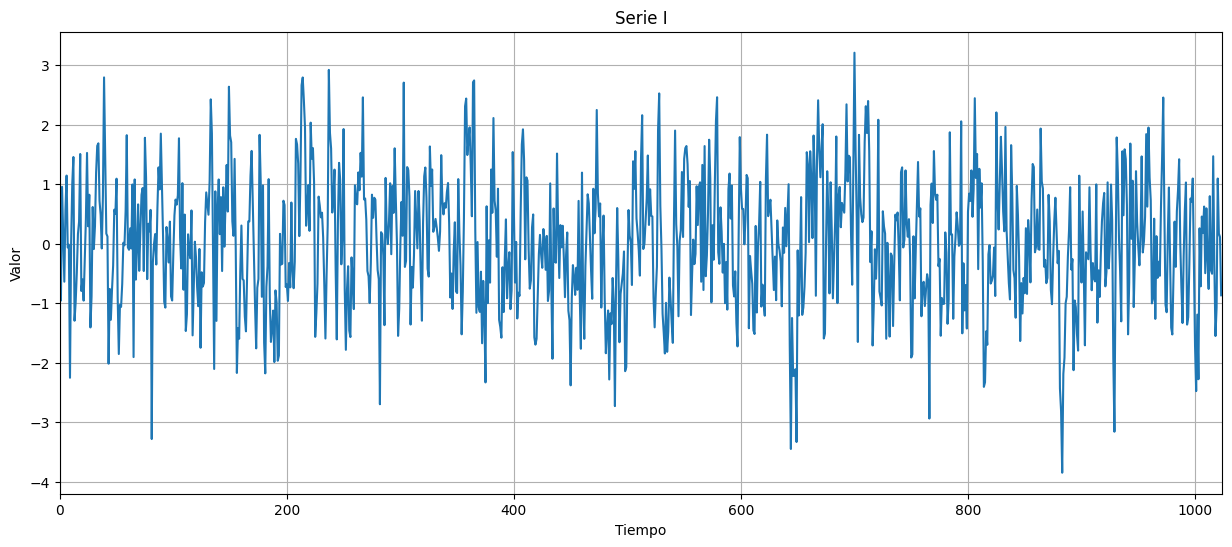

In [5]:
serie1_analisis = AnalisisSerie(series[0], "Serie I")
serie1_analisis.grafico()

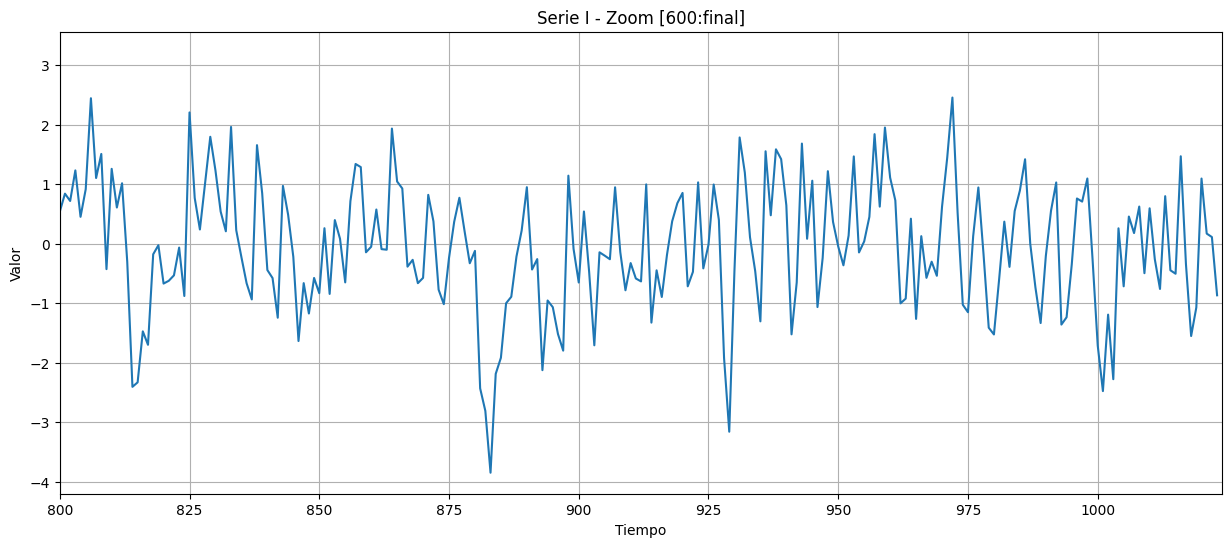

In [6]:
serie1_analisis.grafico(titulo="Serie I - Zoom [600:final]", rango=(800, "auto"))

A simple vista la serie I no tiene tendencia y oscila alrededor de 0, entre -4 y 3.2 aproximadamente. Parece un proceso ARMA.

In [7]:
serie1_analisis.adfuller_tabla()

,Regresión,Estadístico ADF,Valor p,Número de lags
0,Constante,-19.857769,0.0,0
1,Tendencia,-19.883064,0.0,0
2,Cuadrática,-19.876450,0.0,0


La prueba de Dickey Fuller aumentada confirma que hay evidencia para rechazar H0: la serie tiene raíz unitaria.

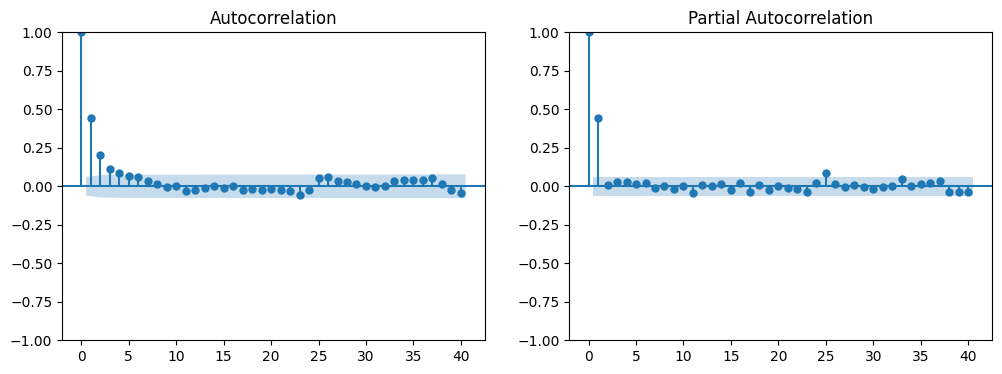

{'acf significativos': [(1, np.float64(0.442)),
  (2, np.float64(0.203)),
  (3, np.float64(0.115)),
  (4, np.float64(0.084))],
 'pacf_significativos': [(1, np.float64(0.442)), (25, np.float64(0.084))]}

In [8]:
serie1_analisis.grafico_acf_pacf(lags=40)

In [9]:
ajuste = serie1_analisis.ajuste_arima(p=1, i=0, q=0)
print(ajuste.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1024
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1424.587
Date:                Sat, 03 Oct 2026   AIC                           2855.174
Time:                        21:26:35   BIC                           2869.968
Sample:                             0   HQIC                          2860.790
                               - 1024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0220      0.055      0.403      0.687      -0.085       0.129
ar.L1          0.4422      0.027     16.171      0.000       0.389       0.496
sigma2         0.9458      0.042     22.518      0.0

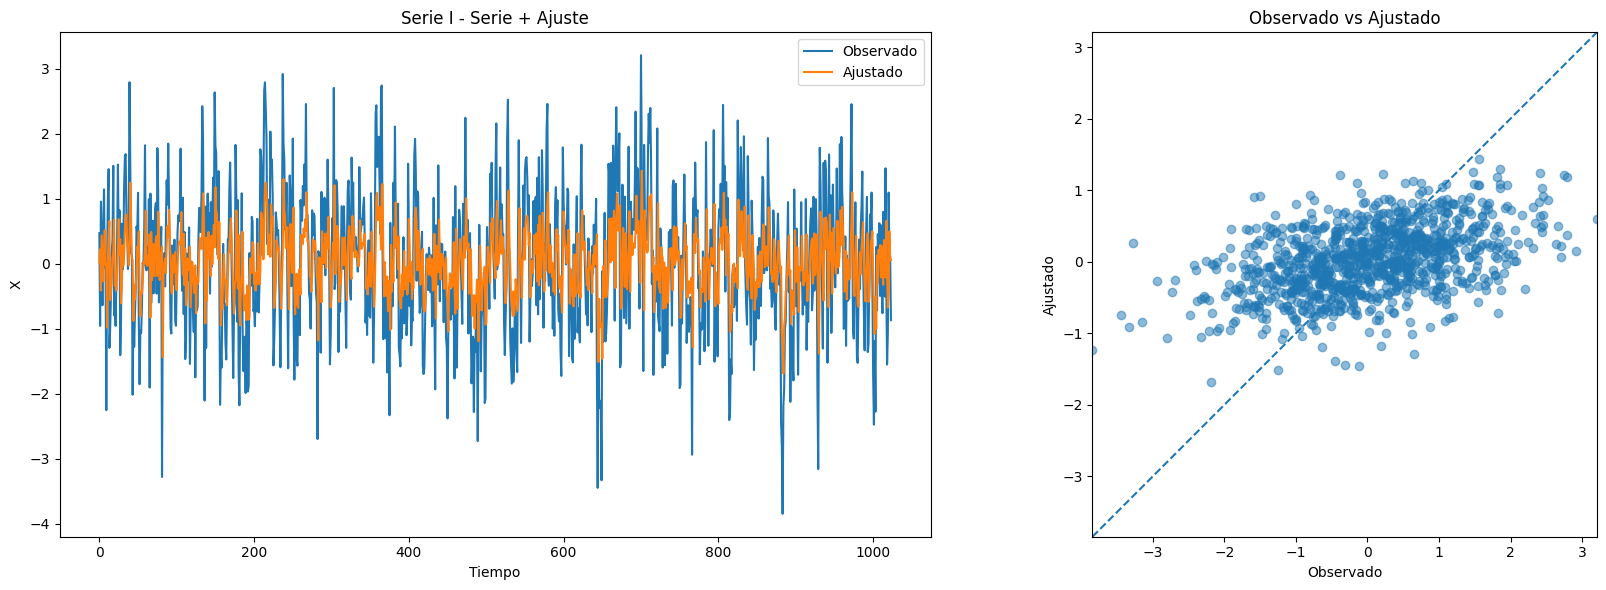

In [10]:
serie1_analisis.grafico_ajuste_vs_original(ajuste)

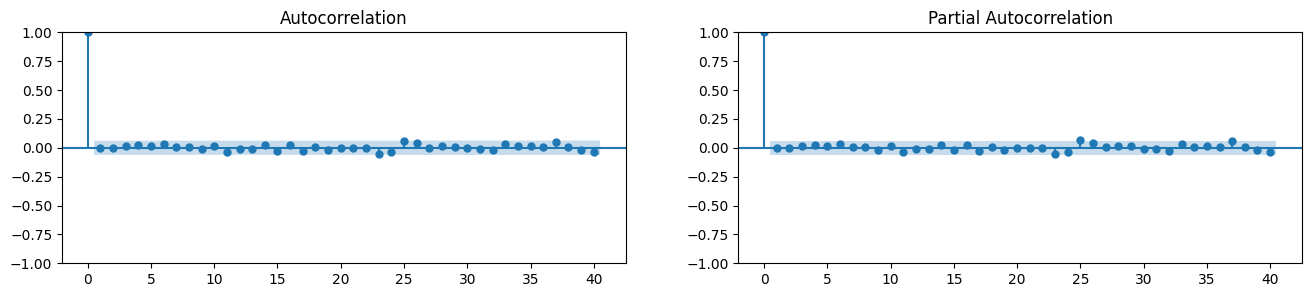

{'acf significativos': [], 'pacf_significativos': []}

In [11]:
serie1_analisis.grafico_residuos(ajuste, lags=40)

## Serie II

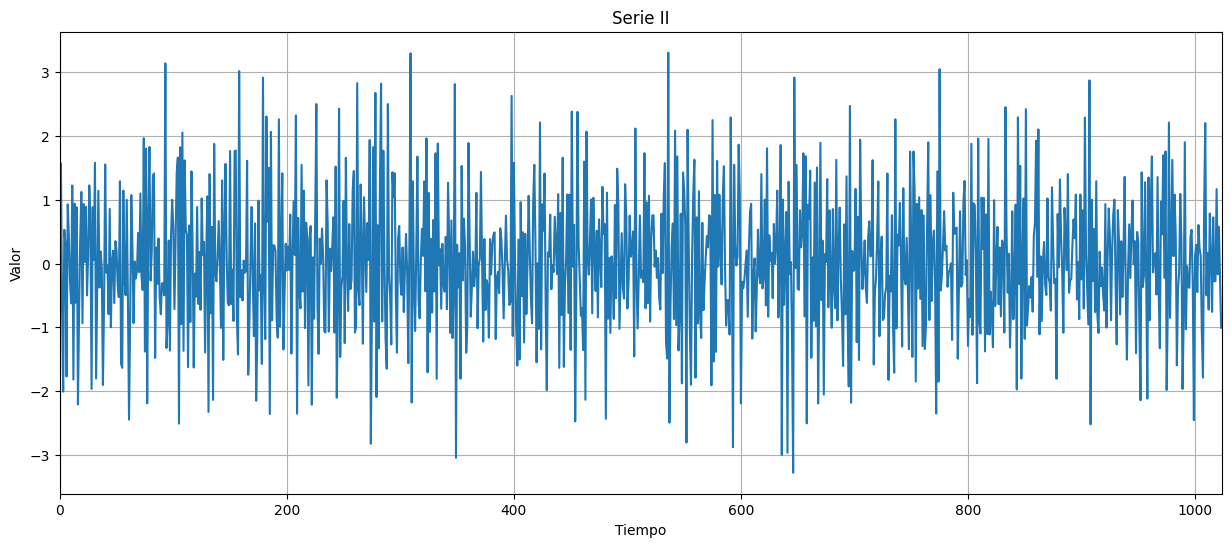

In [12]:
serie2_analisis = AnalisisSerie(series[1], "Serie II")
serie2_analisis.grafico()

In [13]:
serie2_analisis.adfuller_tabla()

,Regresión,Estadístico ADF,Valor p,Número de lags
0,Constante,-26.124569,0.0,2
1,Tendencia,-26.118524,0.0,2
2,Cuadrática,-26.116127,0.0,2


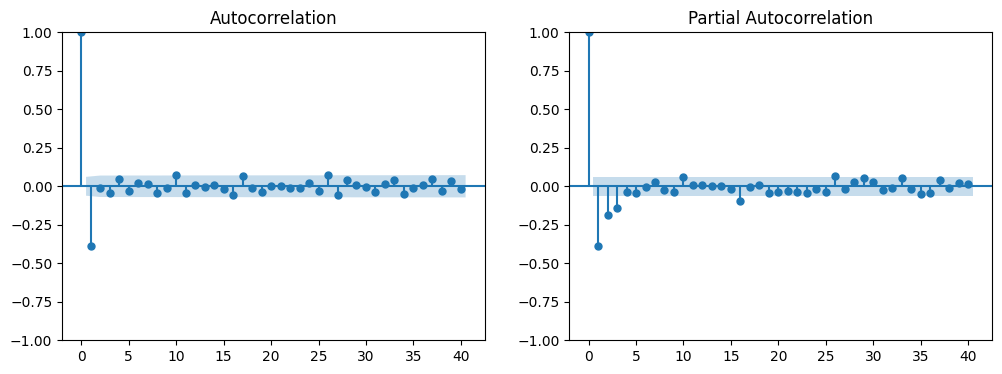

{'acf significativos': [(1, np.float64(-0.385)),
  (10, np.float64(0.075)),
  (26, np.float64(0.075))],
 'pacf_significativos': [(1, np.float64(-0.385)),
  (2, np.float64(-0.187)),
  (3, np.float64(-0.143)),
  (16, np.float64(-0.093)),
  (26, np.float64(0.07))]}

In [14]:
serie2_analisis.grafico_acf_pacf(lags=40)

In [15]:
ajuste =serie2_analisis.ajuste_arima(p=0, i=0, q=1)
print(ajuste.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1024
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1442.084
Date:                Sat, 03 Oct 2026   AIC                           2890.168
Time:                        21:26:36   BIC                           2904.963
Sample:                             0   HQIC                          2895.785
                               - 1024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0229      0.015      1.504      0.133      -0.007       0.053
ma.L1         -0.5075      0.026    -19.359      0.000      -0.559      -0.456
sigma2         0.9786      0.042     23.108      0.0

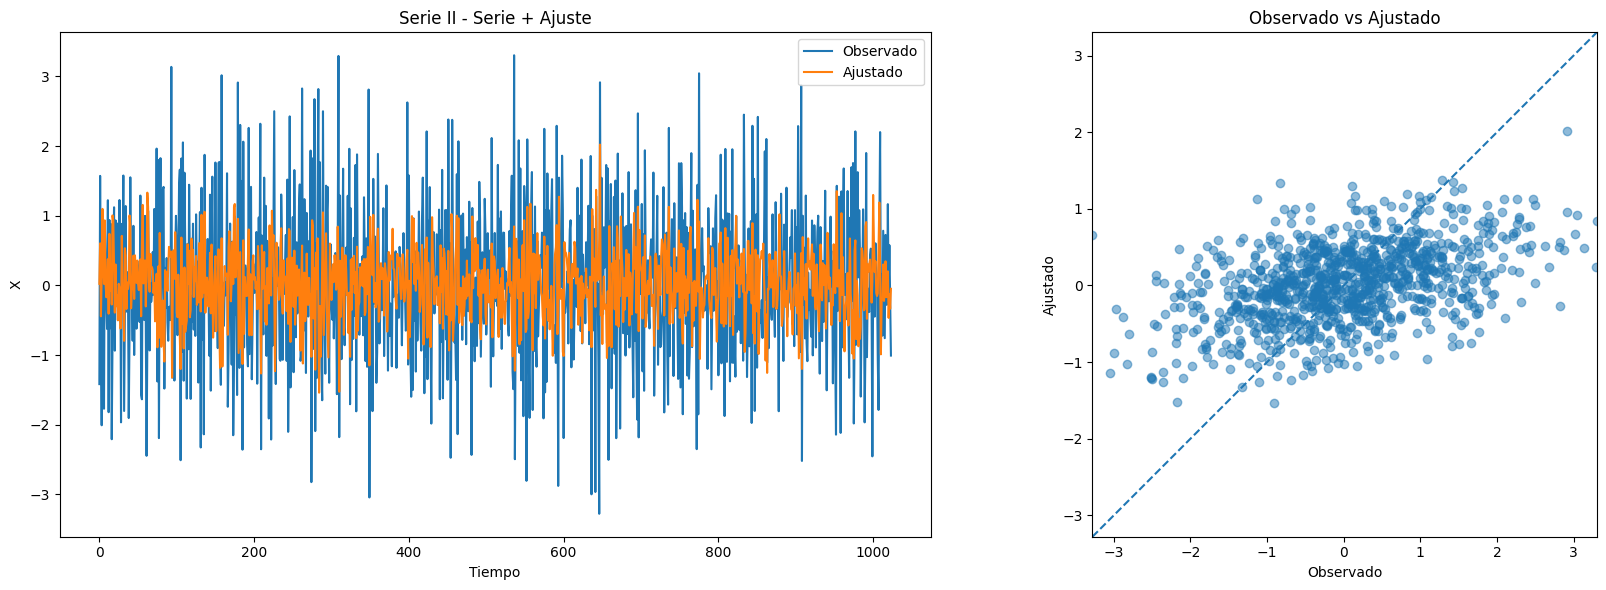

In [16]:
serie2_analisis.grafico_ajuste_vs_original(ajuste)

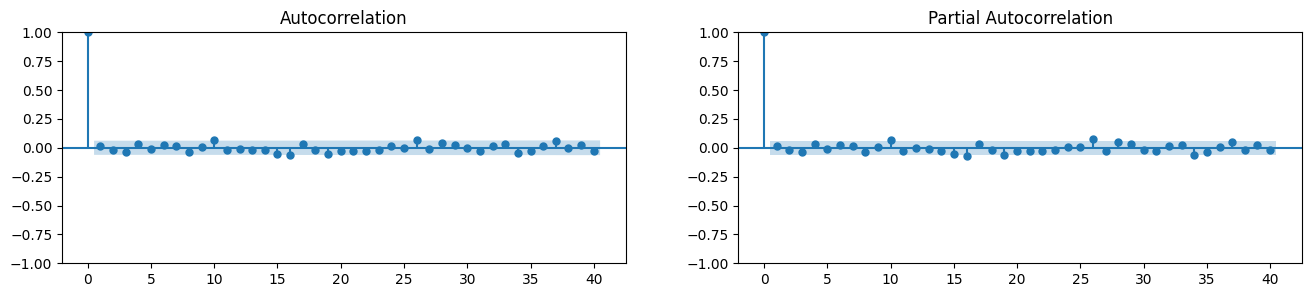

{'acf significativos': [],
 'pacf_significativos': [(16, np.float64(-0.071)), (26, np.float64(0.076))]}

In [17]:
serie2_analisis.grafico_residuos(ajuste,lags=40)

## Serie III

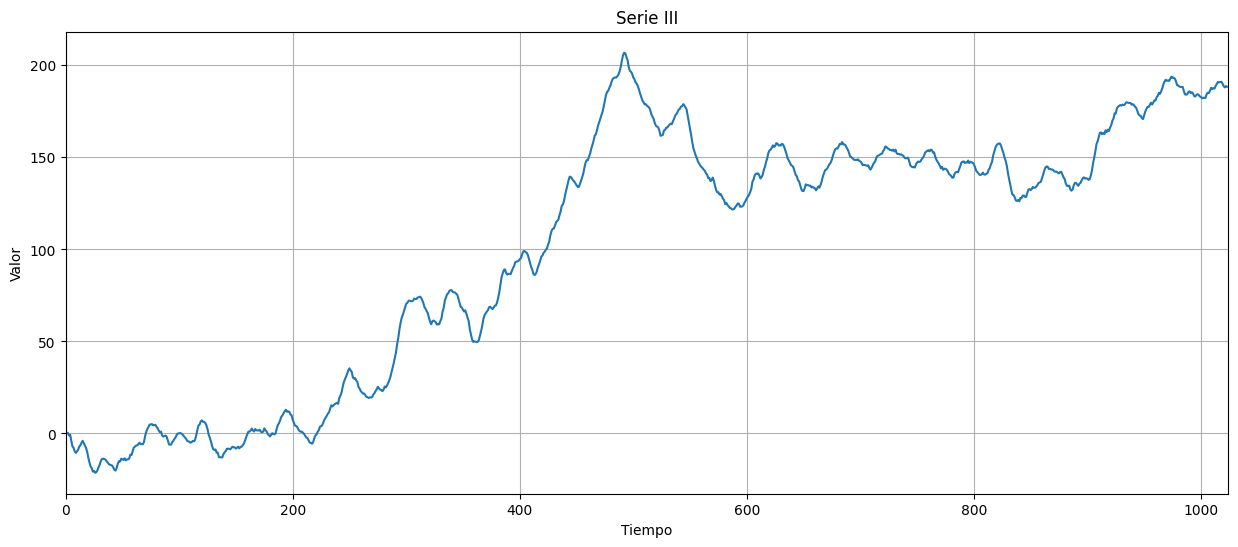

In [18]:
serie3_analisis = AnalisisSerie(series[2], "Serie III")
serie3_analisis.grafico()

In [19]:
serie3_analisis.adfuller_tabla()

,Regresión,Estadístico ADF,Valor p,Número de lags
0,Constante,-1.125546,0.704778,2
1,Tendencia,-2.052355,0.572651,2
2,Cuadrática,-2.893082,0.348513,2


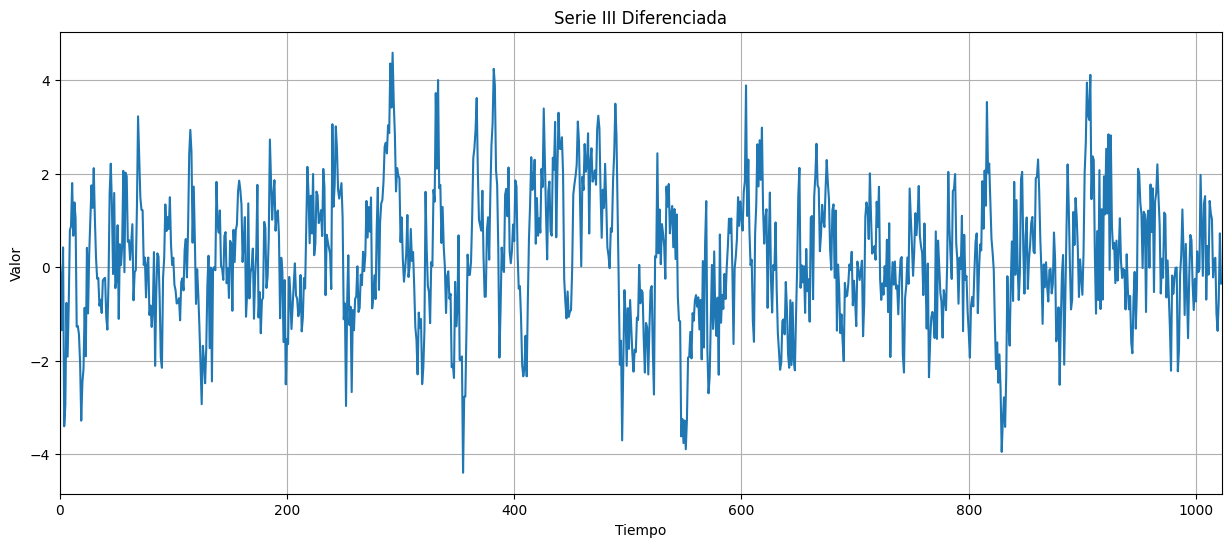

In [20]:
serie3_diferenciada = np.diff(series[2])
serie3_analisis_diferenciada = AnalisisSerie(serie3_diferenciada, "Serie III Diferenciada")
serie3_analisis_diferenciada.grafico()

In [21]:
serie3_analisis_diferenciada.adfuller_tabla()

,Regresión,Estadístico ADF,Valor p,Número de lags
0,Constante,-9.832981,4.980147e-17,1
1,Tendencia,-9.830320,5.311480e-15,1
2,Cuadrática,-9.835917,1.120238e-14,1


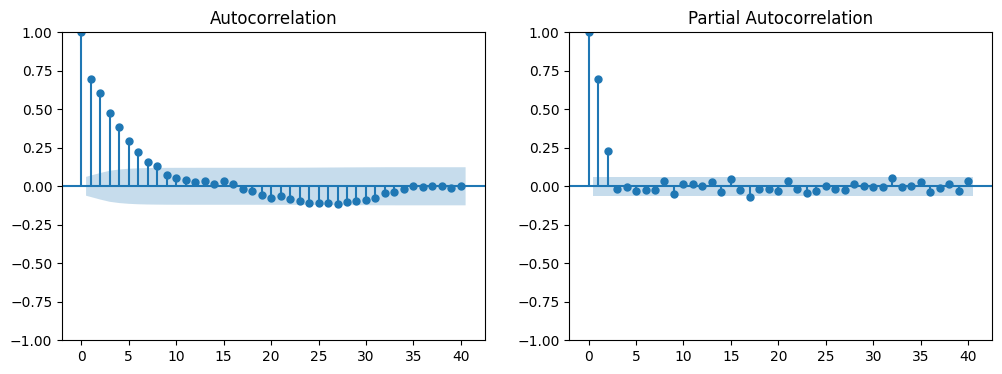

{'acf significativos': [(1, np.float64(0.698)),
  (2, np.float64(0.604)),
  (3, np.float64(0.477)),
  (4, np.float64(0.387)),
  (5, np.float64(0.296)),
  (6, np.float64(0.223)),
  (7, np.float64(0.158)),
  (8, np.float64(0.13))],
 'pacf_significativos': [(1, np.float64(0.698)),
  (2, np.float64(0.227)),
  (17, np.float64(-0.07))]}

In [22]:
serie3_analisis_diferenciada.grafico_acf_pacf(lags=40)

In [23]:
ajuste3 = serie3_analisis.ajuste_arima(2, 1, 0)
print(ajuste3.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1024
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -1441.895
Date:                Sat, 03 Oct 2026   AIC                           2889.790
Time:                        21:26:37   BIC                           2904.582
Sample:                             0   HQIC                          2895.406
                               - 1024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5417      0.031     17.553      0.000       0.481       0.602
ar.L2          0.2288      0.029      7.781      0.000       0.171       0.286
sigma2         0.9805      0.045     21.721      0.0

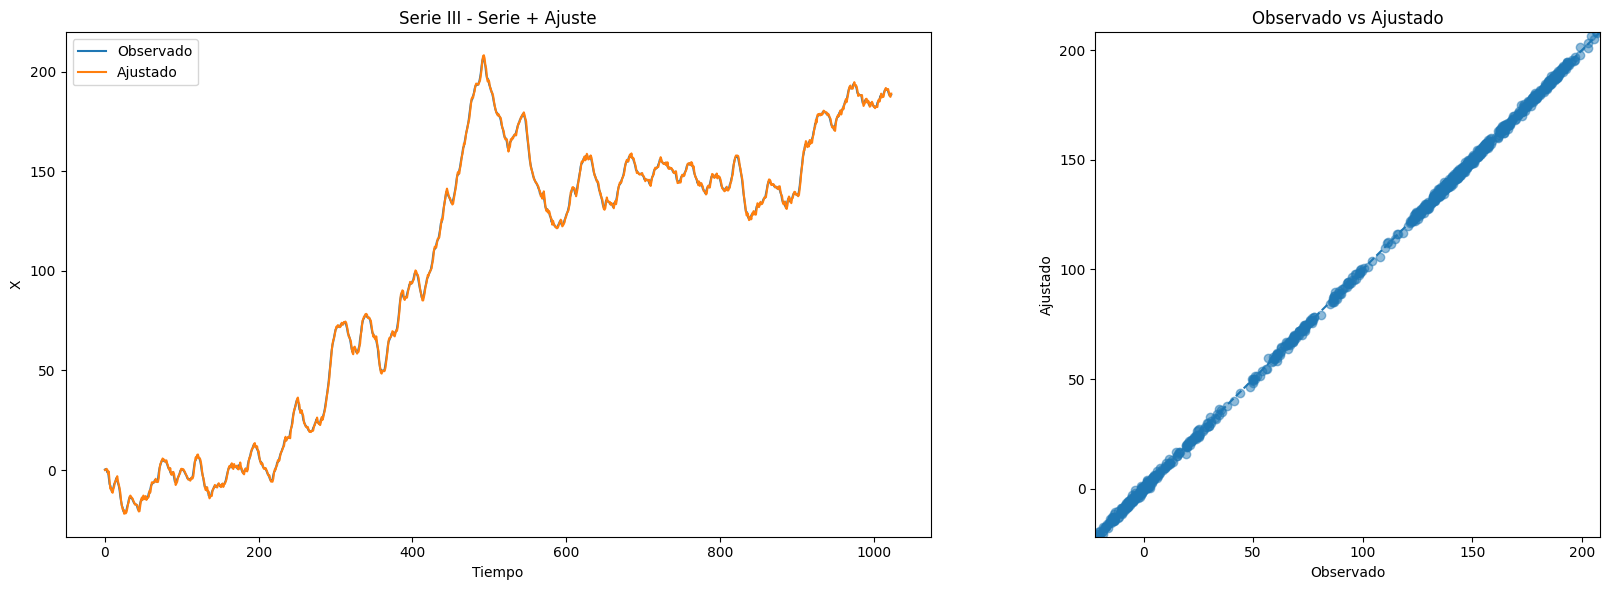

In [24]:
serie3_analisis.grafico_ajuste_vs_original(ajuste3)

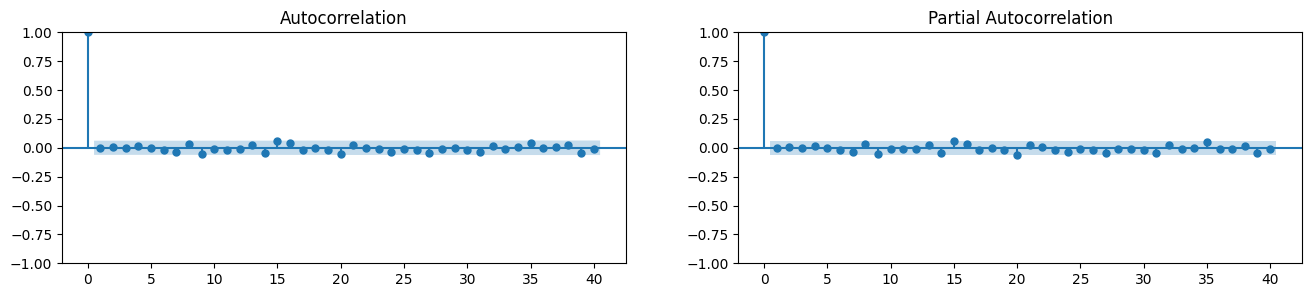

{'acf significativos': [], 'pacf_significativos': []}

In [25]:
serie3_analisis.grafico_residuos(ajuste3, lags=40)

## Serie IV

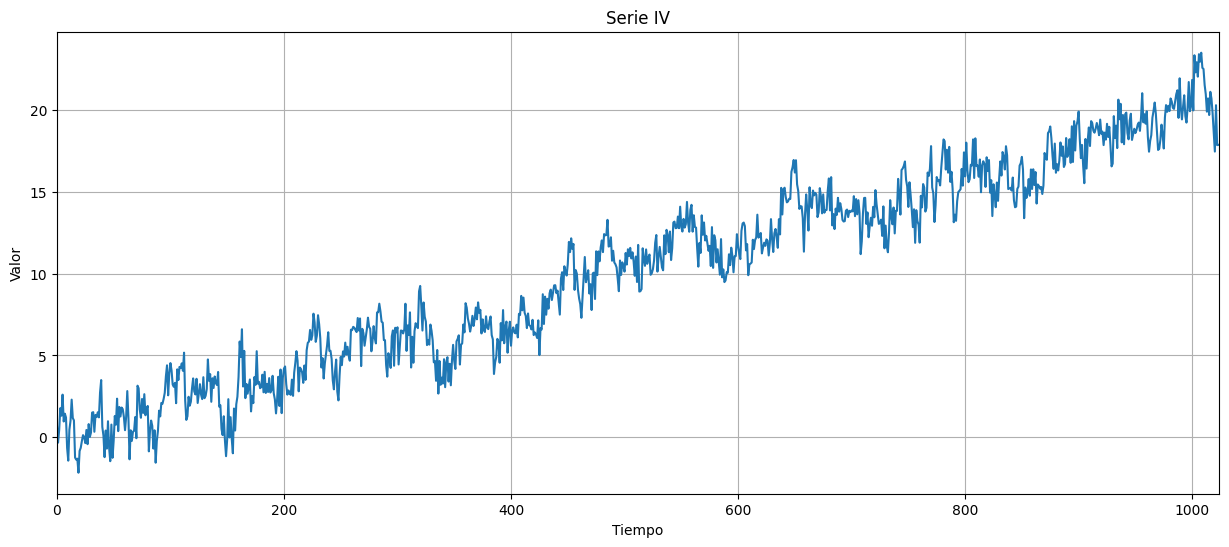

In [26]:
serie4_analisis = AnalisisSerie(series[3], "Serie IV")
serie4_analisis.grafico()

In [27]:
serie4_analisis.adfuller_tabla()

,Regresión,Estadístico ADF,Valor p,Número de lags
0,Constante,-0.810188,8.161111e-01,22
1,Tendencia,-8.835370,8.574827e-13,1
2,Cuadrática,-8.831018,3.084362e-12,1


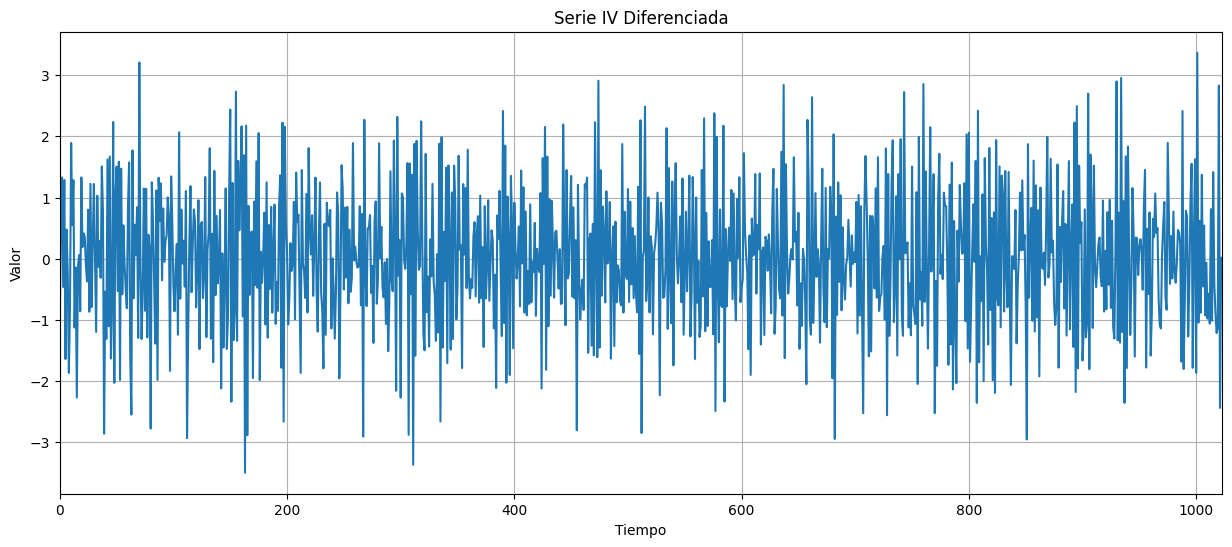

In [28]:
serie4_diferenciada = np.diff(series[3])
serie4_analisis_diferenciada = AnalisisSerie(serie4_diferenciada, "Serie IV Diferenciada")
serie4_analisis_diferenciada.grafico()

In [29]:
serie4_analisis_diferenciada.adfuller_tabla()

,Regresión,Estadístico ADF,Valor p,Número de lags
0,Constante,-10.104981,1.035619e-17,21
1,Tendencia,-10.091120,1.481681e-15,21
2,Cuadrática,-10.081281,2.931820e-15,21


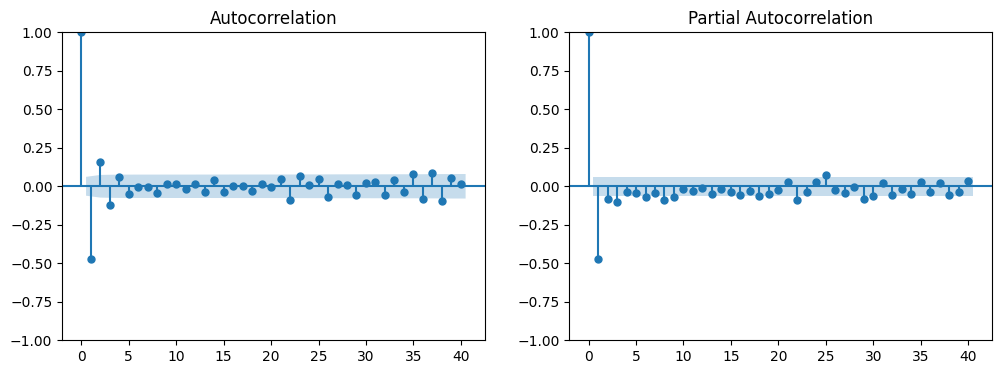

{'acf significativos': [(1, np.float64(-0.472)),
  (2, np.float64(0.159)),
  (3, np.float64(-0.121)),
  (22, np.float64(-0.091)),
  (35, np.float64(0.079)),
  (36, np.float64(-0.082)),
  (37, np.float64(0.089)),
  (38, np.float64(-0.098))],
 'pacf_significativos': [(1, np.float64(-0.472)),
  (2, np.float64(-0.082)),
  (3, np.float64(-0.102)),
  (6, np.float64(-0.067)),
  (8, np.float64(-0.088)),
  (9, np.float64(-0.067)),
  (18, np.float64(-0.066)),
  (22, np.float64(-0.087)),
  (25, np.float64(0.072)),
  (29, np.float64(-0.08))]}

In [30]:
serie4_analisis_diferenciada.grafico_acf_pacf(lags=40)

In [31]:
ajuste4 = serie4_analisis.ajuste_arima(0, 1, 3)
print(ajuste4.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1024
Model:                 ARIMA(0, 1, 3)   Log Likelihood               -1464.224
Date:                Sat, 03 Oct 2026   AIC                           2936.448
Time:                        21:26:39   BIC                           2956.170
Sample:                             0   HQIC                          2943.935
                               - 1024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5374      0.031    -17.340      0.000      -0.598      -0.477
ma.L2          0.1108      0.034      3.271      0.001       0.044       0.177
ma.L3         -0.1415      0.031     -4.623      0.0

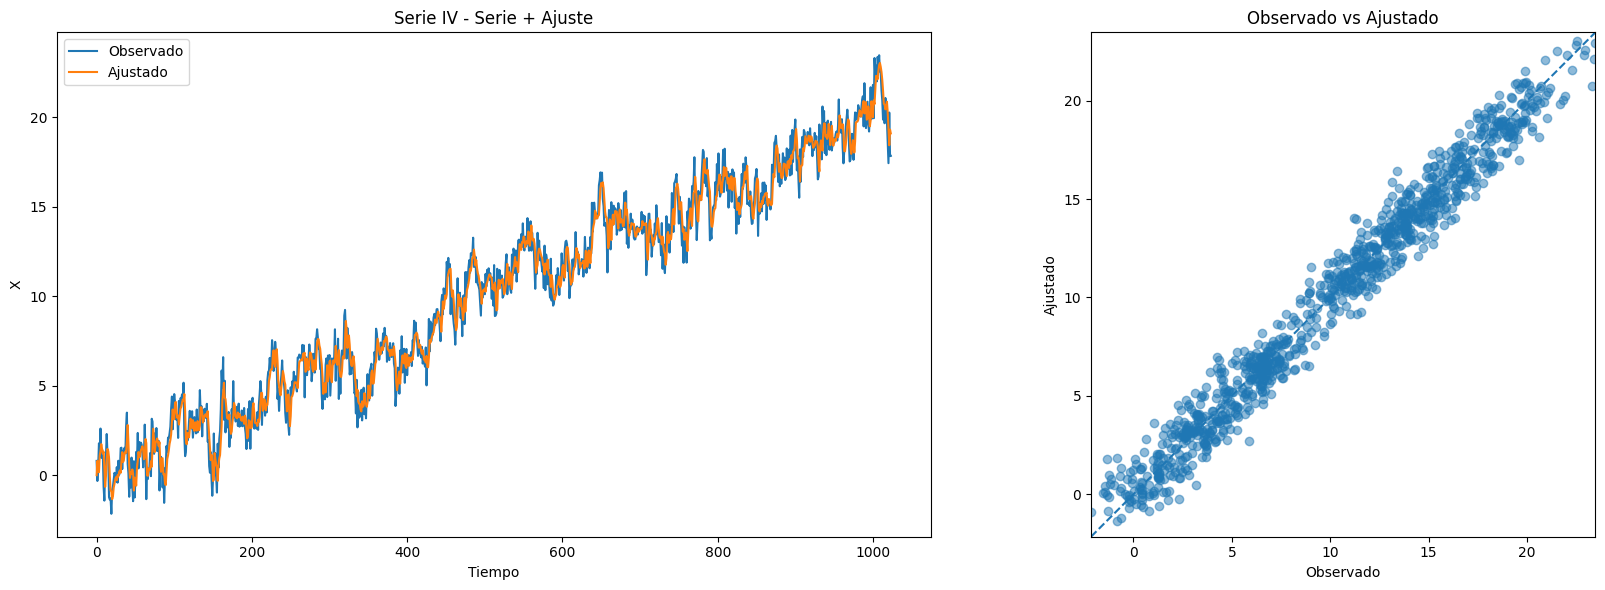

In [32]:
serie4_analisis.grafico_ajuste_vs_original(ajuste4)

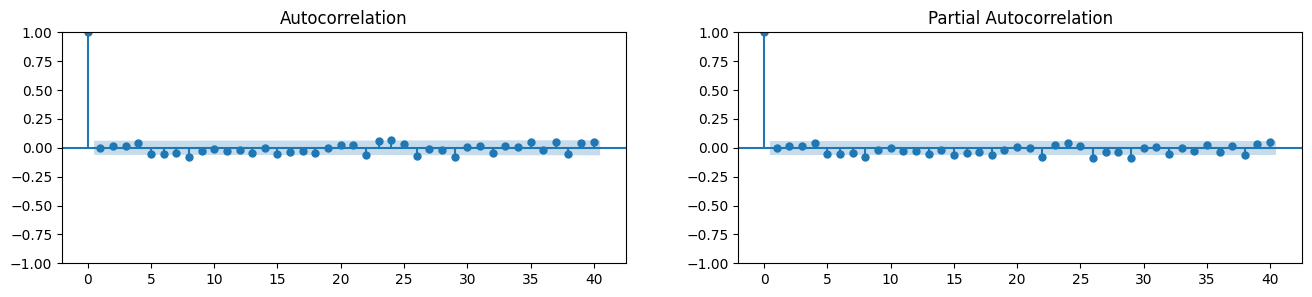

{'acf significativos': [(8, np.float64(-0.08)), (29, np.float64(-0.078))],
 'pacf_significativos': [(8, np.float64(-0.08)),
  (22, np.float64(-0.084)),
  (26, np.float64(-0.084)),
  (29, np.float64(-0.089))]}

In [33]:
serie4_analisis.grafico_residuos(ajuste4, lags=40)

## Serie V

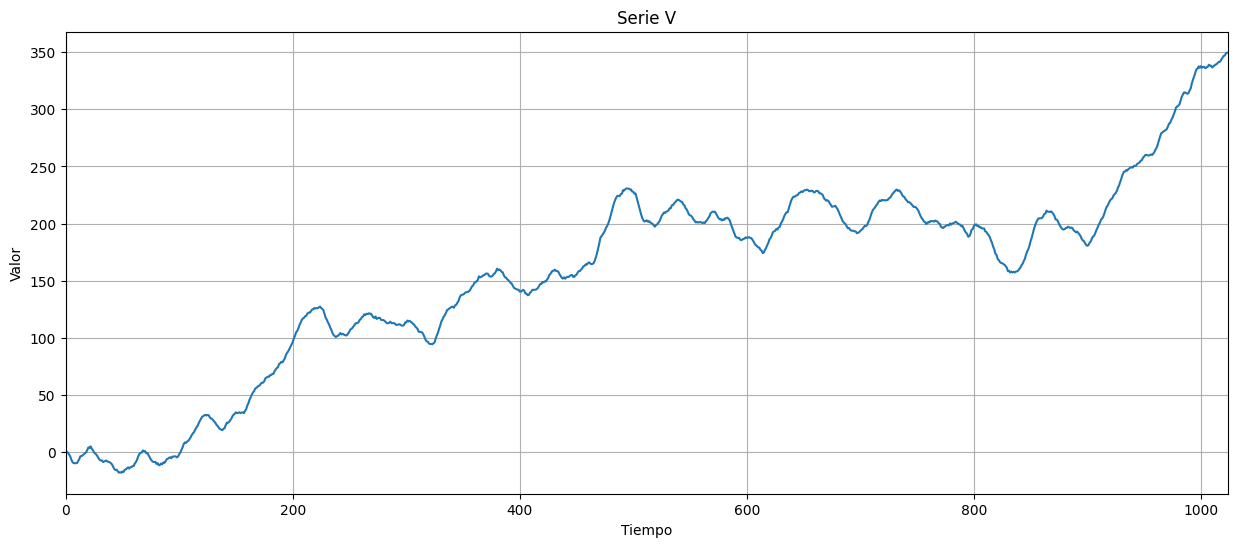

In [34]:
serie5_analisis = AnalisisSerie(series[4], "Serie V")
serie5_analisis.grafico()

In [35]:
serie5_analisis.adfuller_tabla()

,Regresión,Estadístico ADF,Valor p,Número de lags
0,Constante,-0.609383,0.868848,2
1,Tendencia,-2.095258,0.548751,2
2,Cuadrática,-1.675264,0.913573,2


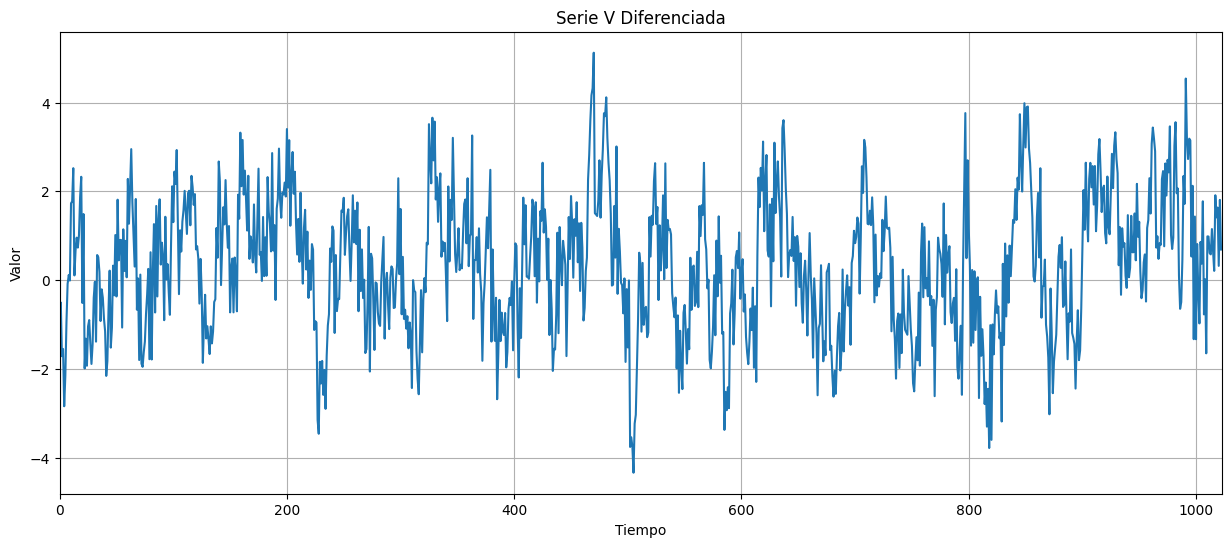

In [36]:
serie5_diferenciada = np.diff(series[4])
serie5_analisis_diferenciada = AnalisisSerie(serie5_diferenciada, "Serie V Diferenciada")
serie5_analisis_diferenciada.grafico()

In [37]:
serie5_analisis_diferenciada.adfuller_tabla()

,Regresión,Estadístico ADF,Valor p,Número de lags
0,Constante,-8.268656,4.860168e-13,1
1,Tendencia,-8.271254,1.687716e-11,1
2,Cuadrática,-8.369140,4.192638e-11,1


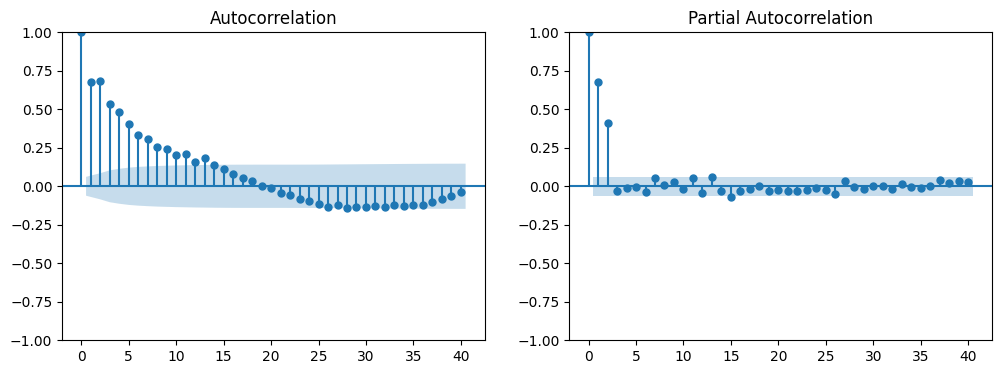

{'acf significativos': [(1, np.float64(0.679)),
  (2, np.float64(0.682)),
  (3, np.float64(0.537)),
  (4, np.float64(0.484)),
  (5, np.float64(0.402)),
  (6, np.float64(0.334)),
  (7, np.float64(0.307)),
  (8, np.float64(0.256)),
  (9, np.float64(0.245)),
  (10, np.float64(0.201)),
  (11, np.float64(0.211)),
  (12, np.float64(0.159)),
  (13, np.float64(0.185))],
 'pacf_significativos': [(1, np.float64(0.679)),
  (2, np.float64(0.41)),
  (15, np.float64(-0.067))]}

In [38]:
serie5_analisis_diferenciada.grafico_acf_pacf(lags=40)

In [39]:
ajuste5 = serie5_analisis.ajuste_arima(2, 1, 0)
print(ajuste5.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1024
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -1468.899
Date:                Sat, 03 Oct 2026   AIC                           2943.797
Time:                        21:26:40   BIC                           2958.589
Sample:                             0   HQIC                          2949.413
                               - 1024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4053      0.027     14.833      0.000       0.352       0.459
ar.L2          0.4166      0.029     14.562      0.000       0.361       0.473
sigma2         1.0334      0.049     21.255      0.0

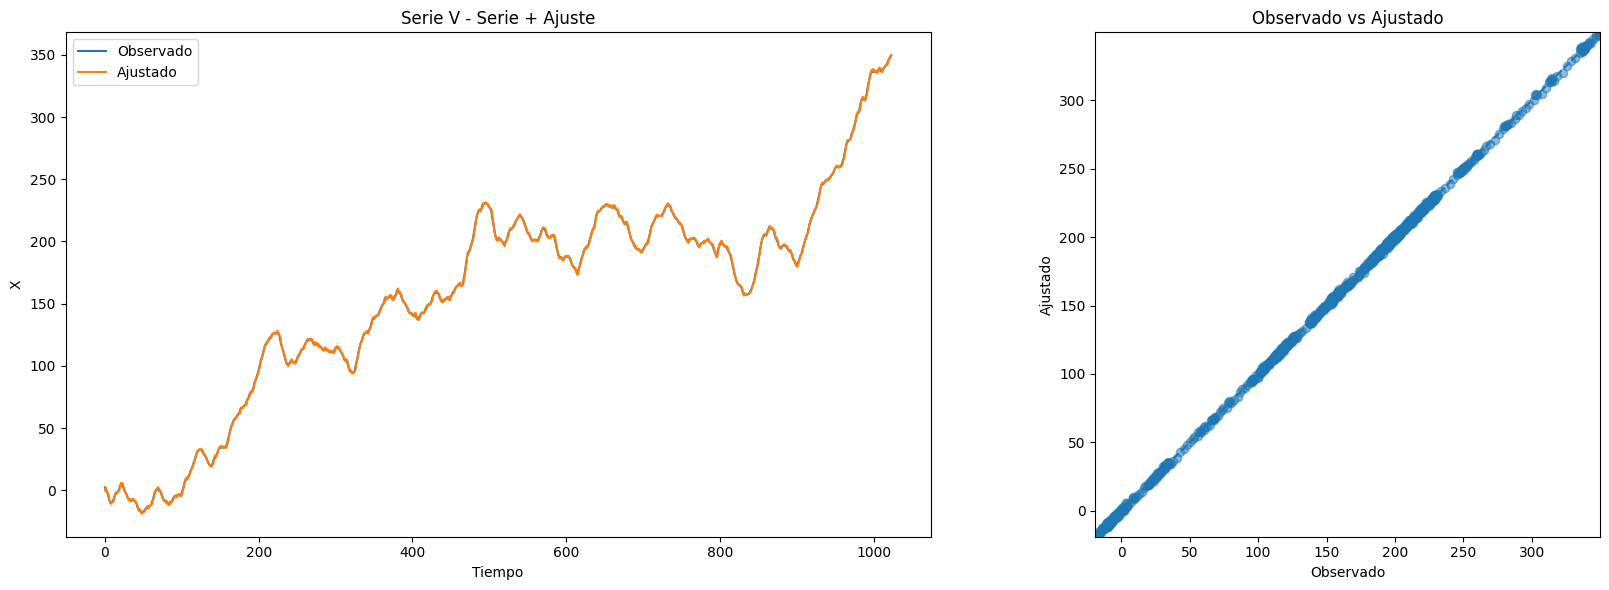

In [40]:
serie5_analisis.grafico_ajuste_vs_original(ajuste5)

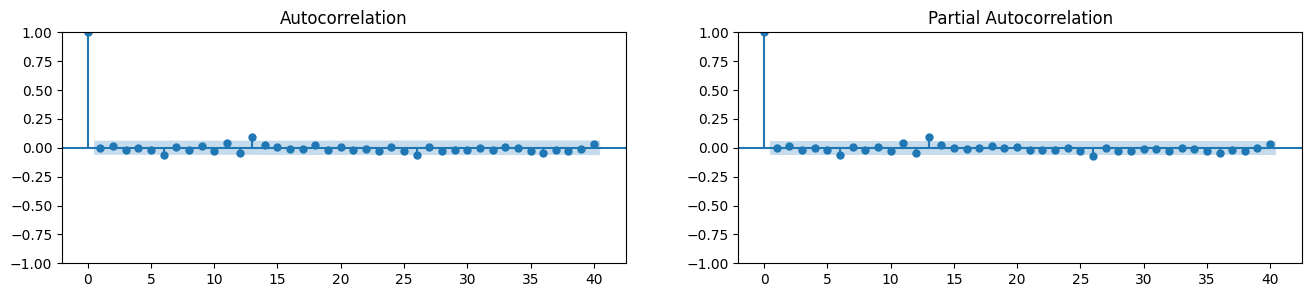

{'acf significativos': [(13, np.float64(0.096))],
 'pacf_significativos': [(13, np.float64(0.095)), (26, np.float64(-0.072))]}

In [41]:
serie5_analisis.grafico_residuos(ajuste5, lags=40)

## Serie VI

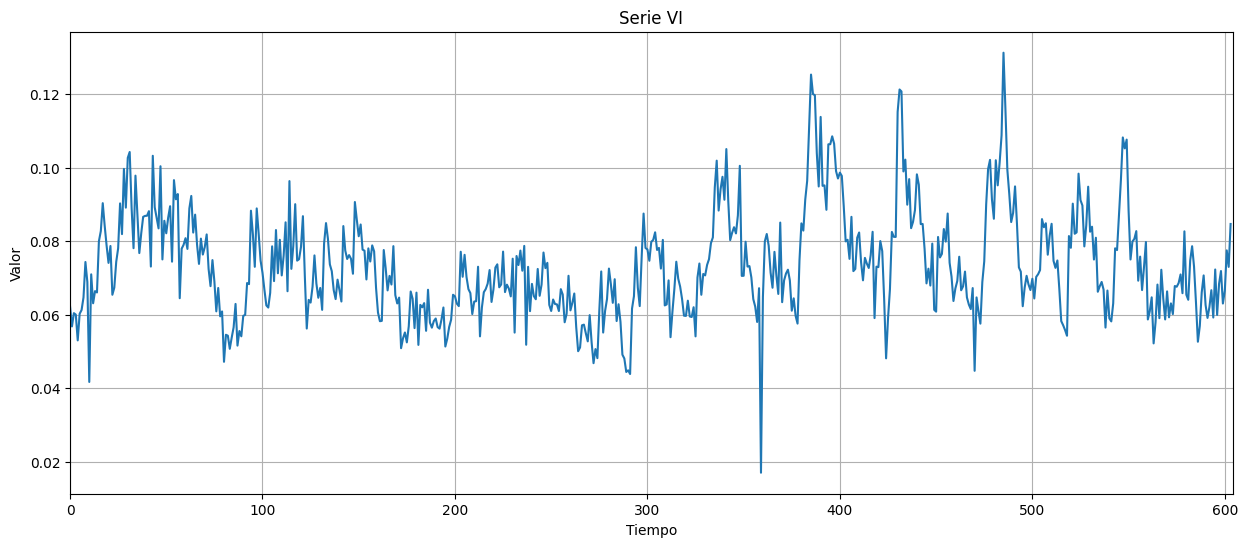

In [42]:
serie6_analisis = AnalisisSerie(series[5], "Serie VI")
serie6_analisis.grafico()

In [43]:
serie6_analisis.adfuller_tabla()

,Regresión,Estadístico ADF,Valor p,Número de lags
0,Constante,-6.373478,2.314240e-08,1
1,Tendencia,-6.397577,3.091612e-07,1
2,Cuadrática,-6.428396,1.561853e-06,1


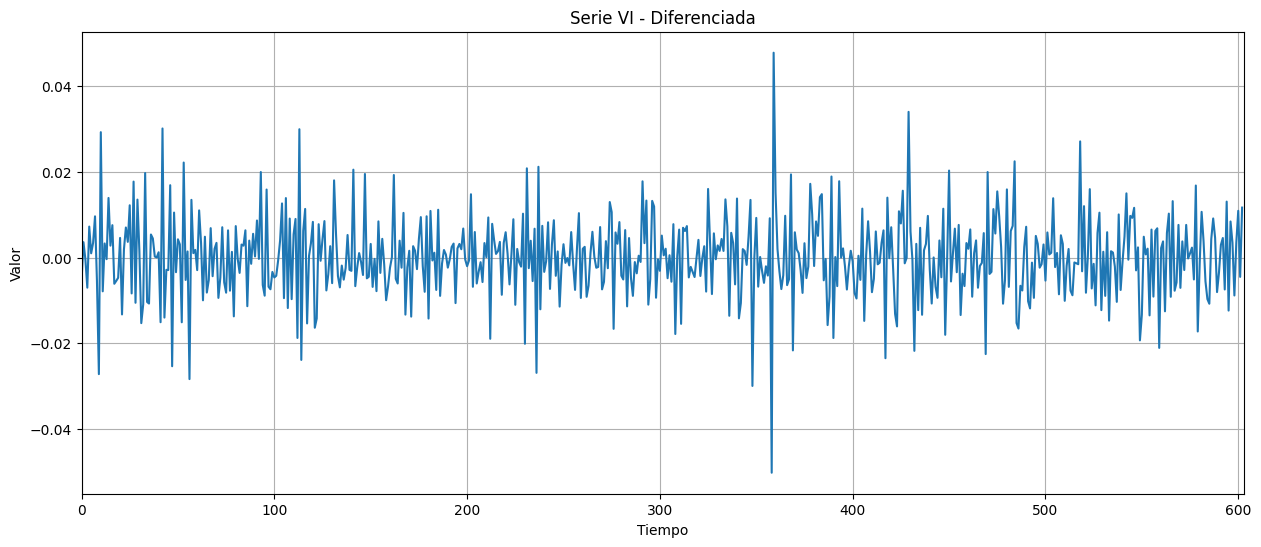

In [44]:
serie6_diferenciada = np.diff(series[5])
serie6_analisis_diferenciada = AnalisisSerie(serie6_diferenciada, "Serie VI - Diferenciada")
serie6_analisis_diferenciada.grafico()

In [45]:
serie6_analisis_diferenciada.adfuller_tabla()

,Regresión,Estadístico ADF,Valor p,Número de lags
0,Constante,-8.578266,7.854707e-14,19
1,Tendencia,-8.566548,3.528724e-12,19
2,Cuadrática,-8.558760,1.436738e-11,19


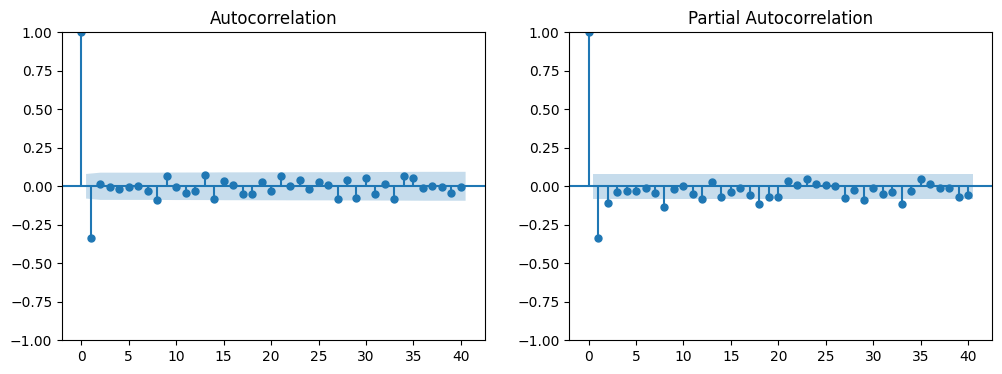

{'acf significativos': [(1, np.float64(-0.337))],
 'pacf_significativos': [(1, np.float64(-0.337)),
  (2, np.float64(-0.111)),
  (8, np.float64(-0.132)),
  (12, np.float64(-0.084)),
  (18, np.float64(-0.113)),
  (29, np.float64(-0.089)),
  (33, np.float64(-0.118))]}

In [46]:
serie6_analisis_diferenciada.grafico_acf_pacf(lags=40)

In [47]:
ajuste6 = serie6_analisis.ajuste_arima(0, 1, 1)
print(ajuste6.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  604
Model:                 ARIMA(0, 1, 1)   Log Likelihood                1985.909
Date:                Sat, 03 Oct 2026   AIC                          -3967.818
Time:                        21:26:41   BIC                          -3959.014
Sample:                             0   HQIC                         -3964.392
                                - 604                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3794      0.030    -12.535      0.000      -0.439      -0.320
sigma2      8.065e-05   3.41e-06     23.665      0.000     7.4e-05    8.73e-05
Ljung-Box (L1) (Q):                   0.00   Jarque-

/home/nadia/unsl/series/sandbox/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


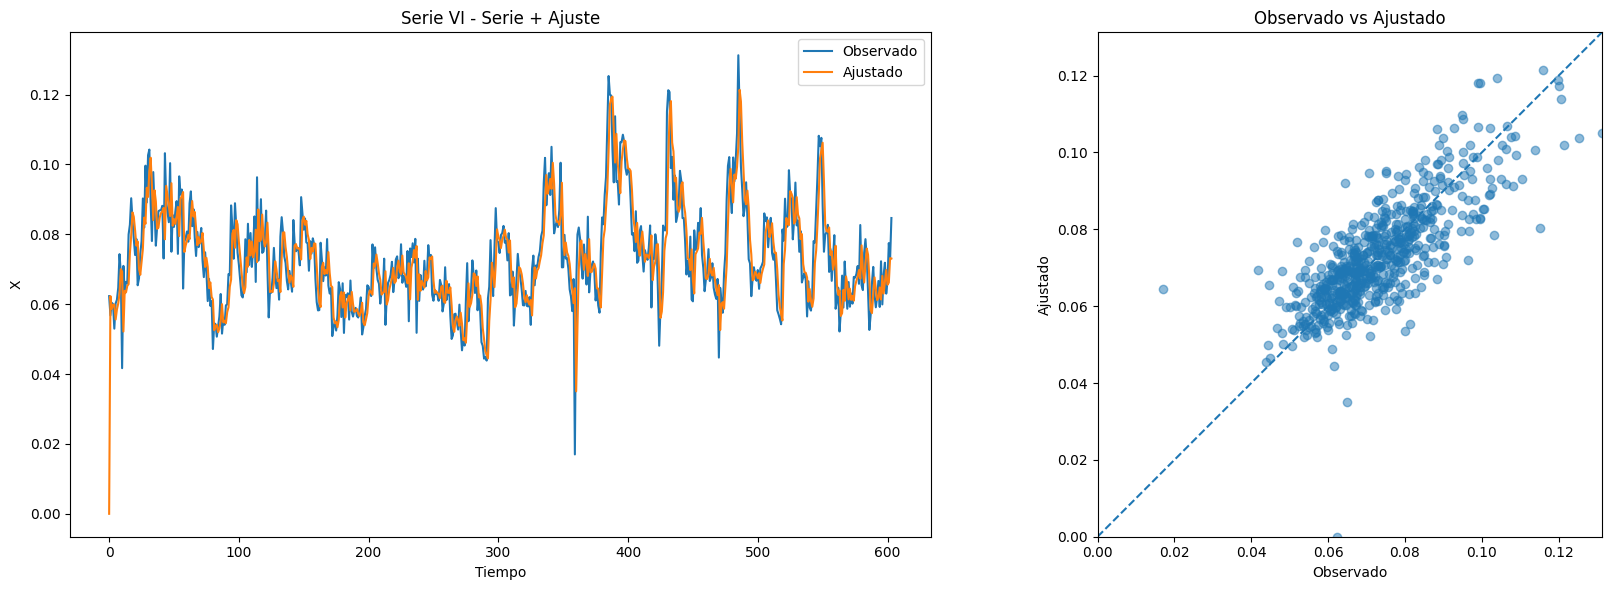

In [48]:
serie6_analisis.grafico_ajuste_vs_original(ajuste6)

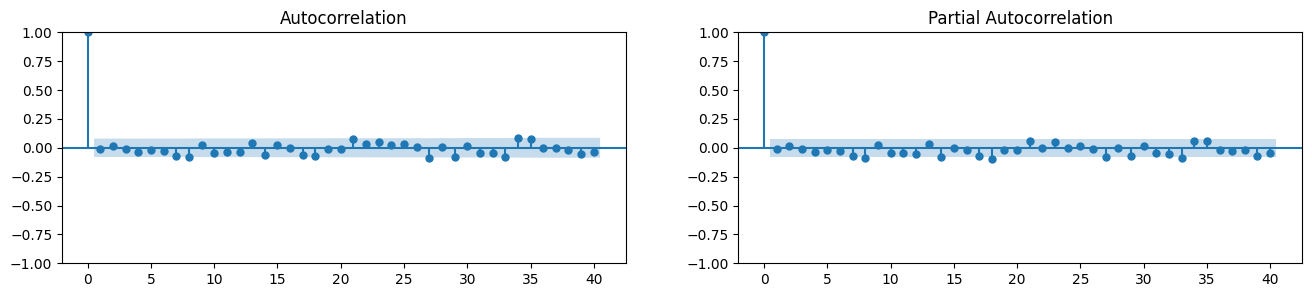

{'acf significativos': [], 'pacf_significativos': [(18, np.float64(-0.097))]}

In [49]:
serie6_analisis.grafico_residuos(ajuste6, lags=40)